# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team


Provide your GitHub Link here.
https://github.com/dinesh1462




# **Project Summary -**

Objective:
This project aimed to analyze Netflix’s content library using unsupervised machine learning to group movies and TV shows into meaningful clusters. The goal was to uncover hidden patterns in content types, genres, ratings, and production trends to support marketing strategies, content acquisition, and personalized recommendations.

Exploratory Data Analysis (EDA):

A comprehensive EDA revealed significant insights:

Content Trends: Movies dominate, but TV shows have grown rapidly since 2015.

Audience Ratings: Most content targets mature viewers (TV-MA).

Geography: Content is largely produced in the USA and India.

Genres: Top genres include Drama, Comedy, Documentaries, and Action.

Durations & Seasons:

Movie durations analyzed with histograms, KDEs, and boxplots.

TV show seasons distribution visualized with bar plots and boxplots by rating.

Temporal Patterns: Scatter plots of release year vs. year added showed acquisition timing trends.

Statistical Testing: Pearson correlation and ANOVA confirmed relationships between release year, addition year, and durations across ratings.

EDA highlighted patterns, outliers, and trends, providing a strong foundation for clustering.

Data Preprocessing & Feature Engineering:

Filled missing categorical fields (director, cast, country) with 'Unknown'.

Dropped rows with missing critical fields (date_added, rating) and reset the index.

Combined textual features (genre, description, director, cast) into a single column.

Applied text cleaning: contraction expansion, lowercasing, punctuation/URL/digit removal.

Converted text into TF-IDF vectors for numeric representation.

Visualized outliers in movie duration and release year for better understanding.

Clustering Approach:

Two clustering algorithms were implemented:

K-Means:

Scaled numeric features using StandardScaler.

Optimal clusters determined with Silhouette Score.

PCA used for 2D visualization.

Cluster labels stored as cluster_optimized.

Agglomerative Hierarchical Clustering:

Dendrogram on a sample determined cluster count.

Full dataset clustered with n_clusters=12, labels stored as cluster_agg.

Results & Impact:

Identified clear thematic clusters like International Crime Dramas, Stand-up Comedy Specials, Animated Family Movies, and Documentaries.

Business Applications:

Targeted marketing campaigns.

Data-driven content acquisition strategy.

Enhanced recommendation systems for improved user experience.

Conclusion:

This project successfully transformed Netflix’s raw content data into actionable insights using EDA, text preprocessing, dimensionality reduction, and clustering. The resulting clusters provide a data-driven framework for understanding, segmenting, and leveraging Netflix’s content library for strategic decision-making.

# **GitHub Link -**

https://github.com/dinesh1462

# **Problem Statement**


Netflix has a vast and constantly growing library of movies and TV shows, making it challenging to understand the underlying structure of its content. The platform needs a way to categorize and segment content beyond simple metadata such as genre, release year, or rating. Traditional filtering methods are limited in revealing hidden patterns, thematic similarities, or underserved content areas.

The objective of this project is to use unsupervised machine learning to cluster Netflix’s content library into meaningful groups, uncovering relationships between genres, ratings, cast, directors, and descriptions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')
print(df.head())


In [ ]:
show_id     type  title           director  \
0      s1  TV Show     3%                NaN
1      s2    Movie   7:19  Jorge Michel Grau
2      s3    Movie  23:59       Gilbert Chan
3      s4    Movie      9        Shane Acker
4      s5    Movie     21     Robert Luketic

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States

          date_added  release_year rating   duration  \
0    August 14, 2020          2020  TV-MA  4 Seasons
1  December 23, 2016          2016  TV-MA     93 min
2  December 20, 2018          2011      R     78 min
3  November 16, 2017          2009  PG-13     80 min
4    January 1, 2020          2008  PG-13    123 min

                                           listed_in  \
0  International TV Shows, TV Dramas, TV Sci-Fi &...
1                       Dramas, International Movies
2                Horror Movies, International Movies
3  Action & Adventure, Independent Movies, Sci-Fi...
4                                             Dramas

                                         description
0  In a future where the elite inhabit an island ...
1  After a devastating earthquake hits Mexico Cit...
2  When an army recruit is found dead, his fellow...
3  In a postapocalyptic world, rag-doll robots hi...
4  A brilliant group of students become card-coun...


### Dataset First View

In [ ]:
# Dataset First Look
print(df.head())

In [ ]:
 show_id     type  title           director  \
0      s1  TV Show     3%                NaN
1      s2    Movie   7:19  Jorge Michel Grau
2      s3    Movie  23:59       Gilbert Chan
3      s4    Movie      9        Shane Acker
4      s5    Movie     21     Robert Luketic

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States

          date_added  release_year rating   duration  \
0    August 14, 2020          2020  TV-MA  4 Seasons
1  December 23, 2016          2016  TV-MA     93 min
2  December 20, 2018          2011      R     78 min
3  November 16, 2017          2009  PG-13     80 min
4    January 1, 2020          2008  PG-13    123 min

                                           listed_in  \
0  International TV Shows, TV Dramas, TV Sci-Fi &...
1                       Dramas, International Movies
2                Horror Movies, International Movies
3  Action & Adventure, Independent Movies, Sci-Fi...
4                                             Dramas

                                         description
0  In a future where the elite inhabit an island ...
1  After a devastating earthquake hits Mexico Cit...
2  When an army recruit is found dead, his fellow...
3  In a postapocalyptic world, rag-doll robots hi...
4  A brilliant group of students become card-coun...

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(df.shape)

In [ ]:
(7787, 12)

### Dataset Information

In [ ]:
# Dataset Info
print(df.info())

In [ ]:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 395.5+ KB
None

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"There are {duplicate_count} duplicate rows in the dataset.")

In [ ]:
There are 0 duplicate rows in the dataset.

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print(df.isnull().sum())

In [ ]:
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [ ]:
# Visualizing the missing values
missing = df.isnull().astype(int)

plt.figure(figsize=(12,6))
plt.imshow(missing.T, aspect='auto', cmap='viridis', interpolation='nearest')
plt.title('Missing Values Heatmap')
plt.xlabel('Rows')
plt.ylabel('Columns')
plt.colorbar(label='Missing (1) / Present (0)')
plt.yticks(ticks=np.arange(len(df.columns)), labels=df.columns)
plt.show()

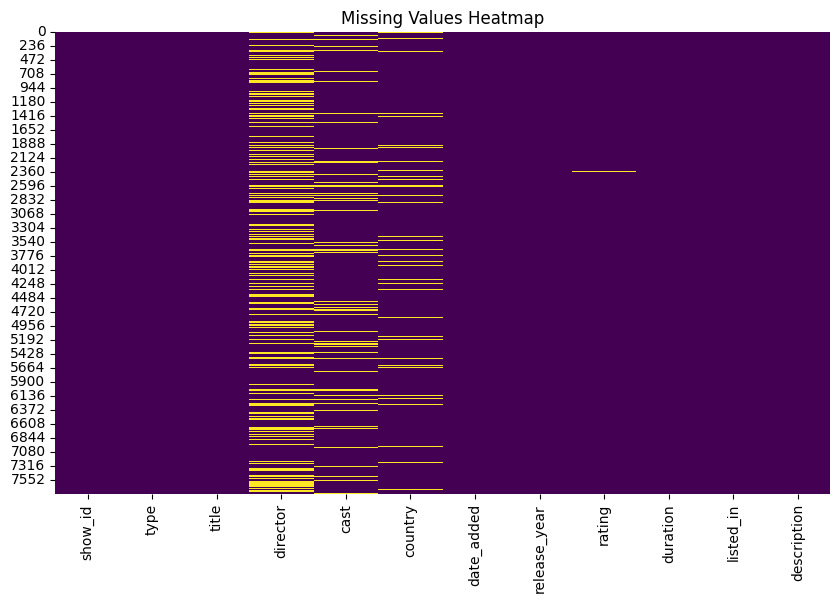

### What did you know about your dataset?

The Netflix dataset has 7,787 rows and 12 columns, mostly strings, with release_year as integer. Key missing values: director (2,389), cast (718), country (507), and few in date_added & rating. These will be handled before analysis for accurate results.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
# Dataset Describe
print(df.describe())

       release_year
count   7787.000000
mean    2013.932580
std        8.757395
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2018.000000
max     2021.000000

### Variables Description

title: Movie/TV show name

type: Movie or TV Show

director, cast, country: Key creators & production location

date_added, release_year: Added to Netflix & original release year

rating: Maturity rating

duration: Movie minutes / TV seasons

listed_in: Genres/categories

description: Content synopsis

features: Combined text (genre + description + director + cast) for clustering

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"--- Unique Values in '{column}' ---")
    print(df[column].unique())
    print("\n" + "="*50 + "\n")

--- Unique Values in 'show_id' ---
['s1' 's2' 's3' ... 's7785' 's7786' 's7787']

==================================================

--- Unique Values in 'type' ---
['TV Show' 'Movie']

==================================================

--- Unique Values in 'title' ---
['3%' '7:19' '23:59' ... 'Zulu Man in Japan' "Zumbo's Just Desserts"
 "ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS"]

==================================================

--- Unique Values in 'director' ---
[nan 'Jorge Michel Grau' 'Gilbert Chan' ... 'Josef Fares' 'Mozez Singh'
 'Sam Dunn']

==================================================

--- Unique Values in 'cast' ---
['João Miguel, Bianca Comparato, Michel Gomes, Rodolfo Valente, Vaneza Oliveira, Rafael Lozano, Viviane Porto, Mel Fronckowiak, Sergio Mamberti, Zezé Motta, Celso Frateschi'
 'Demián Bichir, Héctor Bonilla, Oscar Serrano, Azalia Ortiz, Octavio Michel, Carmen Beato'
 'Tedd Chan, Stella Chung, Henley Hii, Lawrence Koh, Tommy Kuan, Josh Lai, Mark Lee, Susan Leong, Benjamin Lim'
 ...
 'Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanana, Manish Chaudhary, Meghna Malik, Malkeet Rauni, Anita Shabdish, Chittaranjan Tripathy'
 'Nasty C' 'Adriano Zumbo, Rachel Khoo']

==================================================

--- Unique Values in 'country' ---
['Brazil' 'Mexico' 'Singapore' 'United States' 'Turkey' 'Egypt' 'India'
 'Poland, United States' 'Thailand' 'Nigeria' nan
 'Norway, Iceland, United States' 'United Kingdom' 'Japan' 'South Korea'
 'Italy' 'Canada' 'Indonesia' 'Romania' 'Spain' 'Iceland'
 'South Africa, Nigeria' 'France' 'United States, South Africa'
 'Portugal, Spain' 'Hong Kong, China, Singapore' 'United States, Germany'
 'South Africa, China, United States' 'Argentina'
 'United States, France, Serbia' 'Germany' 'Denmark, France, Poland'
 'Poland' 'Kenya' 'New Zealand, United Kingdom' 'Pakistan' 'Australia'
 'Australia, United States' 'Mexico, United States' 'United States, China'
 'China, Hong Kong' 'Taiwan' 'United States, United Kingdom'
 'France, South Korea, Japan' 'United States, Canada'
 'United Kingdom, United States' 'Netherlands, Denmark, South Africa'
 'Canada, United States' 'Denmark' 'Hong Kong'
 'France, Netherlands, Singapore' 'China' 'Philippines'
 'United Kingdom, Spain, United States'
 'United Arab Emirates, United States' 'Netherlands'
 'United Kingdom, Hong Kong' 'Iran, France'
 'United States, United Kingdom, France'
 'United Kingdom, France, Belgium, United States, China'
 'Argentina, Brazil, France, Poland, Germany, Denmark'
 'Israel, United States' 'United States, Mexico'
 'Uruguay, Argentina, Spain' 'Singapore, France'
 'United Kingdom, United States, France, Germany' 'Turkey, United States'
 'Bulgaria, United States' 'Australia, France'
 'Hong Kong, Iceland, United States' 'United Arab Emirates'
 'United States, Chile' 'Germany, France, Russia'
 'Mauritius, South Africa' 'United States, Japan' 'Lebanon'
 'United States, Bulgaria' 'Colombia' 'Uruguay, Argentina'
 'Egypt, Algeria' 'France, Egypt' 'Uruguay' 'Soviet Union, India'
 'Sweden, United States' 'South Africa' 'Malaysia'
 'Ireland, United Kingdom, United States' 'Spain, Italy'
 'United Kingdom, France, Germany' 'United States, Germany, Canada'
 'United States, India' 'Japan, United States' 'Denmark, United States'
 'South Africa, United States' 'Canada, Luxembourg'
 'Serbia, United States' 'Canada, Nigeria' 'Iceland, Sweden, Belgium'
 'Ireland, Canada' 'United States, Italy' 'Finland' 'India, Germany'
 'China, Spain, South Korea, United States' 'Spain, Belgium'
 'United Kingdom, Canada, United States, Germany'
 'Brazil, Netherlands, United States, Colombia, Austria, Germany'
 'France, Canada, Belgium'
 'India, United Kingdom, China, Canada, Japan, South Korea, United States'
 'France, Belgium' 'Indonesia, South Korea, Singapore' 'Norway' 'Peru'
 'France, Senegal, Belgium' 'Canada, France' 'Chile'
 'Romania, France, Switzerland, Germany'
 'Bulgaria, United States, Spain, Canada' 'Sweden, Netherlands' 'Ghana'
 'France, United States, Mexico'
 'Australia, United Kingdom, United Arab Emirates, Canada'
 'Singapore, United States' 'Japan, Canada, United States' 'Saudi Arabia'
 'Australia, Armenia, Japan, Jordan, Mexico, Mongolia, New Zealand, Philippines, South Africa, Sweden, United States, Uruguay'
 'United States, France' 'Norway, Denmark, Netherlands, Sweden' 'Namibia'
 'Mexico, Finland' 'United States, Australia' 'Russia' 'Australia, Canada'
 'United Kingdom, Ireland' 'Belgium, France' 'New Zealand'
 'Uruguay, Spain, Mexico' 'South Korea, China'
 'United States, Canada, Indonesia, United Kingdom, China, Singapore'
 'India, Iran' 'United States, France, Japan' 'United Kingdom, France'
 'Turkey, India' 'Philippines, Qatar' 'Vietnam'
 'Ireland, Luxembourg, Belgium'
 'Saudi Arabia, Syria, Egypt, Lebanon, Kuwait' 'Russia, United States'
 'United Kingdom, Russia, United States' 'Argentina, Spain'
 'Germany, Jordan, Netherlands' 'Hong Kong, China'
 'Argentina, United States' 'France, Belgium, Spain'
 'Germany, United States' 'Denmark, Sweden, Israel, United States'
 'Ireland, United Kingdom' 'United States, Iceland'
 'United Arab Emirates, United Kingdom, India' 'Sweden'
 'Norway, Germany, Sweden' 'Finland, France' 'Denmark, Spain'
 'United Kingdom, Russia' 'United States, United Kingdom, Australia'
 'India, United Kingdom' 'United States, Canada, Ireland'
 'Canada, United Kingdom' 'United States, Israel, Italy, South Africa'
 'India, United States' 'United Kingdom, China' 'Indonesia, Singapore'
 'Netherlands, Denmark, France, Germany' 'South Korea, Japan'
 'Philippines, Canada, United Kingdom, United States'
 'France, Malta, United States' 'Kuwait' 'United Kingdom, Pakistan'
 'Ireland' 'France, New Zealand'
 'United Kingdom, United States, Australia'
 'United Kingdom, Czech Republic, United States, Germany, Bahamas'
 'United States, Australia, China' 'China, Germany, India, United States'
 'Germany, Sri Lanka' 'United States, Sweden'
 'Canada, United States, Cayman Islands' 'India, France'
 'United Kingdom, Canada' 'United States, India, Bangladesh'
 'United States, Canada, France' 'Taiwan, China, France, United States'
 'Brazil, France, Germany' 'United States,'
 'Turkey, France, Germany, Poland' 'Australia, New Zealand, United States'
 'Germany, United States, Hong Kong, Singapore'
 'France, Germany, Switzerland' 'Mexico, Argentina'
 'Italy, United States, Argentina'
 'Germany, France, Luxembourg, United Kingdom, United States'
 'Canada, United States, United Kingdom' 'United Kingdom, Canada, Italy'
 'Czech Republic, France' 'Zimbabwe'
 'United Kingdom, France, Germany, Spain'
 'Taiwan, Hong Kong, United States, China' 'China, United States'
 'Canada, Brazil' 'United Kingdom, Australia' 'Hungary'
 'Germany, Australia' 'United Kingdom, Poland, United States' 'Bulgaria'
 'Philippines, United States' 'Finland, Germany' 'United States, Thailand'
 'Spain, Belgium, Switzerland, United States, China, United Kingdom'
 'Denmark, Zimbabwe' 'United Kingdom, South Africa'
 'Finland, Sweden, Norway, Latvia, Germany' 'United Kingdom, India'
 'South Africa, United States, New Zealand, Canada' 'France, Qatar'
 'France, Algeria' 'United States, Italy, United Kingdom, Liechtenstein'
 'Denmark, France, Belgium, Italy, Netherlands, United States, United Kingdom'
 'United States, Australia, Mexico'
 'United Kingdom, Czech Republic, Germany, United States'
 'Russia, Poland, Serbia' 'France, China, Japan, United States'
 'United States, South Korea, China' 'Germany, Belgium' 'Chile, Argentina'
 'China, United States, United Kingdom' 'Pakistan, Norway, United States'
 'United Kingdom, Japan, United States' 'Philippines, Singapore'
 'United States, Canada, Belgium, United Kingdom' 'Venezuela'
 'Argentina, Uruguay, Serbia' 'United States, Mexico, Colombia'
 'Colombia, Peru, United Kingdom' 'Brazil, United States'
 'Czech Republic, United States'
 'Canada, France, Italy, Morocco, United States' 'Canada, Spain, France'
 'Hong Kong, United States' 'France, Canada, China, Cambodia'
 'United States, Indonesia' 'Spain, France' 'Spain, Mexico, France'
 'Spain, France, Italy' 'Spain, France, United States'
 'United States, France, Canada' 'Israel' 'Italy, France'
 'United Kingdom, Canada, United States' 'Cambodia, United States'
 'China, Japan' 'United Arab Emirates, United States, United Kingdom'
 'Argentina, Italy' 'United Kingdom, Israel, Russia'
 'Italy, Switzerland, Albania, Poland' 'Spain, Cuba'
 'United States, Brazil' 'United States, France, Mexico'
 'United States, Nicaragua' 'Austria, Germany'
 'United Arab Emirates, Jordan, Lebanon'
 'France, United Kingdom, United States'
 'United Kingdom, United States, Spain, Germany, Greece, Canada'
 'France, Belgium, Luxembourg, Cambodia,' 'Italy, Turkey' 'Brazil, France'
 'India, Turkey' 'Kenya, United States' 'United States, South Korea'
 'South Korea, United States' 'Italy, Canada, France'
 'Thailand, United States' 'United Kingdom, Denmark, Canada, Croatia'
 'Netherlands, Belgium'
 'United Kingdom, Canada, United States, Cayman Islands' 'Italy, Germany'
 'United States, France, United Kingdom, Japan'
 'United States, United Kingdom, Denmark, Sweden'
 'United States, United Kingdom, Italy'
 'United States, France, Canada, Spain' 'Uruguay, Guatemala'
 'Germany, Australia, France, China'
 'United States, United Kingdom, Japan'
 'United States, United Kingdom, Canada'
 'Italy, Switzerland, France, Germany' 'Russia, United States, China'
 'United States, Canada, Germany' 'United States, Czech Republic'
 'Ireland, United States' 'United States, United Arab Emirates'
 'France, Australia, Germany' 'Hong Kong, China, United States'
 'Lebanon, United Arab Emirates, France, Switzerland, Germany'
 'United States, South Korea, Japan' 'Romania, United States'
 'West Germany' 'United States, Ireland' 'Chile, Italy'
 'Ireland, United Kingdom, Italy, United States' 'Belgium' 'Poland,'
 'Slovenia, Croatia, Germany, Czech Republic, Qatar'
 'Canada, United Kingdom, Netherlands'
 'United Kingdom, United States, France' 'Indonesia, United Kingdom'
 'United States, Spain, Germany' 'India, Japan'
 'Switzerland, France, Belgium, United States'
 'China, South Korea, United States' 'United Kingdom, France, Belgium'
 'Canada, Ireland, United States'
 'United Kingdom, United States, Dominican Republic'
 'United States, Senegal' 'Germany, United Kingdom, United States'
 'United States, Canada, United Kingdom' 'Canada, United States, France'
 'United Kingdom, Germany, Canada' 'Argentina, France'
 'South Africa, Germany, Netherlands, France'
 'Canada, United States, United Kingdom, France, Luxembourg'
 'Finland, Germany, Belgium' 'United States, United Kingdom, Germany'
 'Taiwan, China' 'Cambodia' 'Spain, Portugal'
 'Ireland, United States, France' 'Jordan' 'Austria'
 'Germany, United States, Canada'
 'United Kingdom, Germany, Canada, United States'
 'United States, France, Canada, Lebanon, Qatar' 'Indonesia, Netherlands'
 'Netherlands, Belgium, United Kingdom, United States'
 'China, United States, Australia' 'France, Belgium, China, United States'
 'Spain, United Kingdom' 'United States, Chile, Israel' 'Bangladesh'
 'United Kingdom, Norway, Denmark, Germany, Sweden'
 'United States, Japan, Canada' 'Norway, Denmark, Sweden'
 'China, India, Nepal' 'United States, Argentina'
 'Mexico, United States, Spain, Colombia'
 'Colombia, Mexico, United States' 'United Kingdom, Belgium, Sweden'
 'Nigeria, United Kingdom' 'United Kingdom, South Korea'
 'United States, Taiwan' 'Netherlands, Belgium, Germany, Jordan'
 'France, Canada' 'United Kingdom, France, United States'
 'Denmark, Singapore, Canada, United States' 'Denmark, China'
 'Malaysia, Singapore, Hong Kong' 'Norway, United States'
 'United States, Philippines' 'United States, Greece, Brazil'
 'France, United States' 'South Korea, France'
 'United States, Australia, Samoa, United Kingdom' 'Canada, South Africa'
 'United Kingdom, Italy' 'Germany, United Kingdom' 'China, United Kingdom'
 'Argentina, Chile, Peru' 'United States, Russia' 'Uruguay, Germany'
 'Turkey, Azerbaijan' 'United States, China, Hong Kong'
 'Canada, Germany, France, United States'
 'Argentina, United States, Mexico' 'France, United Kingdom, India'
 'China, Taiwan' 'Italy, United Kingdom, France' 'Poland, West Germany'
 'Germany, United States, Sweden' 'Canada, Spain'
 'United Kingdom, France, Belgium, United States' 'France, Japan'
 'Netherlands, Germany, Italy, Canada' 'United States, Cambodia'
 'United States, Greece' 'United States, China, Colombia'
 'United States, Spain, Italy' 'Norway, United Kingdom, France, Ireland'
 'United States, Bermuda, Ecuador' 'United Kingdom, Poland'
 'China, Canada, United States' 'United States, Spain' 'India, Mexico'
 'United Kingdom, West Germany' 'Pakistan, United States'
 'Israel, Sweden, Germany, Netherlands' 'Chile, United States, France'
 'France, Morocco' 'United Kingdom, Germany' 'Georgia, Germany, France'
 'Switzerland, France' 'Turkey, South Korea' 'Italy, India'
 'United States, Botswana' 'United States, Colombia, Mexico'
 'Chile, Argentina, France, Spain, United States'
 'Puerto Rico, United States, Colombia' 'United States, Nigeria'
 'Germany, United States, France' 'Spain, Germany, Denmark, United States'
 'United Kingdom, United States, Japan' 'Netherlands, United States'
 'United States, India, South Korea, China'
 'Denmark, Germany, Belgium, United Kingdom, France'
 'Denmark, Germany, Belgium, United Kingdom, France, Sweden'
 'France, Switzerland, Spain, United States, United Arab Emirates'
 'Norway, Sweden' 'United States, Ireland, United Kingdom, India'
 'United Kingdom, Singapore' 'Spain, Germany' 'Germany, Czech Republic'
 'Denmark, Brazil, France, Portugal, Sweden'
 'Brazil, India, China, United States' 'India, Germany, Austria'
 'Italy, United States' 'Denmark, France, United States, Sweden'
 'Australia, Iraq' 'China, Morocco, Hong Kong' 'Spain, Colombia'
 'Australia, United Arab Emirates' 'Canada, United States, Germany'
 'France, Belgium, Italy' 'United Kingdom, Thailand' 'Venezuela, Colombia'
 'France, Luxembourg, Canada' 'India, Nepal' 'Mexico, Spain'
 'Colombia, United States' 'Colombia, Mexico'
 'France, Germany, Czech Republic, Belgium'
 'Germany, China, United Kingdom' 'Canada, Hungary, United States'
 'Pakistan, United Arab Emirates' 'France, United Kingdom'
 'Spain, United Kingdom, United States' 'United Kingdom, Kenya'
 'United States, Norway, Canada' 'Canada, United States, Ireland'
 'Switzerland, Vatican City, Italy, Germany, France'
 'Portugal, France, Poland, United States' 'France, Japan, United States'
 'United States, New Zealand' 'United States, New Zealand, Japan'
 'United States, Netherlands, Japan, France' 'India, Switzerland'
 'Canada, India' 'Canada, Japan, United States' 'United States, Morocco'
 'United States, Mexico, Spain, Malta' 'Norway, Denmark'
 'South Korea, Canada, United States, China' 'Singapore, Japan, France'
 'Canada, Mexico, Germany, South Africa'
 'United Kingdom, United States, Canada'
 'Germany, France, United States, Canada, United Kingdom'
 'Peru, Germany, Norway' 'Singapore, Malaysia' 'United States, Uruguay'
 'India, Canada' 'Ireland, Canada, United Kingdom, United States'
 'United States, Germany, Australia' 'Senegal' 'Israel, Germany, France'
 'Australia, France, Ireland' 'South Africa, Angola'
 'Austria, Czech Republic' 'Australia, India'
 'United States, United Kingdom, Canada, Japan'
 'Sweden, United Kingdom, Finland' 'Hong Kong, Taiwan'
 'United States, United Kingdom, Spain, South Korea'
 'South Korea, China, United States' 'Guatemala' 'Ukraine'
 'United States, United Kingdom, Canada, China'
 'Italy, South Africa, West Germany, Australia, United States'
 'United Kingdom, Finland, Germany' 'South Africa, United States, Germany'
 'United States, Germany, United Kingdom, Australia' 'India, Soviet Union'
 'Italy, France, Switzerland' 'Canada, France, United States'
 'United States, Colombia' 'India, Malaysia' 'Switzerland, United States'
 'Thailand, Canada, United States' 'China, Hong Kong, United States'
 'United Kingdom, New Zealand'
 'United Kingdom, France, Germany, United States'
 'South Korea, Czech Republic' 'Czech Republic, United Kingdom, France'
 'Australia, United Kingdom, Canada'
 'Canada, United Kingdom, United States' 'United States, Hungary'
 'Jamaica, United States' 'Switzerland'
 'Australia, United Kingdom, United States, New Zealand, Italy, France'
 'France, United States, Canada' 'Australia, United Kingdom'
 'United States, Denmark'
 'United Kingdom, France, Canada, Belgium, United States'
 'Denmark, United Kingdom, Sweden' 'Belarus' 'Cyprus'
 'Lebanon, United States, United Arab Emirates' 'United States, Hong Kong'
 'United States, Kazakhstan'
 'Argentina, France, United States, Germany, Qatar'
 'United States, Germany, United Kingdom'
 'United States, Germany, United Kingdom, Italy'
 'United States, New Zealand, United Kingdom' 'Finland, United States'
 'Spain, France, Uruguay' 'France, Belgium, United States'
 'France, Canada, United States' 'Spain, Argentina'
 'United Kingdom, India, United States' 'Chile, France'
 'United States, United Kingdom, France, Germany, Japan' 'Canada, Norway'
 'United States, Hungary, Ireland, Canada' 'United States, Canada, China'
 'United Kingdom, Malawi'
 'Ireland, Canada, Luxembourg, United States, United Kingdom, Philippines, India'
 'United States, Czech Republic, United Kingdom' 'Ghana, United States'
 'Israel, Germany' 'Spain, Mexico' 'Mexico, France'
 'Brazil, United Kingdom'
 'France, Belgium, Luxembourg, Romania, Canada, United States'
 'Israel, Germany, Poland, Luxembourg, Belgium, France, United States'
 'France, Germany' 'United States, Malta, France, United Kingdom'
 'United Kingdom, United States, Germany, Denmark, Belgium, Japan'
 'Austria, United States' 'Canada, Australia' 'Greece, United States'
 'United Kingdom, France, Belgium, Canada, United States'
 'Argentina, Chile' 'Czech Republic, Slovakia'
 'United Kingdom, Germany, United States, France'
 'United Kingdom, Lithuania' 'Egypt, France' 'Spain, France, Canada'
 'United States, Greece, United Kingdom'
 'United Kingdom, China, United States, India' 'Taiwan, Malaysia'
 'United States, Sweden, Norway' 'United Kingdom, United States, Morocco'
 'United States, United Kingdom, Morocco' 'United States, China, Canada'
 'Spain, Canada, United States' 'Canada, Belgium'
 'United States, India, United Arab Emirates'
 'United Kingdom, Canada, France, United States'
 'Spain, Thailand, United States' 'Canada, Germany, South Africa'
 'India, Germany, France' 'United States, Israel, United Kingdom, Canada'
 'United Kingdom, Hungary, Australia' 'Lebanon, France'
 'Belgium, Ireland, Netherlands, Germany, Afghanistan' 'Chile, Peru'
 'Paraguay, Argentina'
 'United Kingdom, Italy, Israel, Peru, United States' 'Norway, Germany'
 'France, Canada, Italy, United States, China'
 'Netherlands, Germany, Denmark, United Kingdom' 'France, Lebanon'
 'Ireland, United Kingdom, Greece, France, Netherlands'
 'Denmark, Indonesia, Finland, Norway, United Kingdom, Israel, France, United States, Germany, Netherlands'
 'New Zealand, United States' 'Argentina, Uruguay, Spain, France'
 'United Kingdom, Germany, United States'
 'United States, Australia, South Africa, United Kingdom' 'Italy, Belgium'
 'United States, Germany, Mexico' 'Chile, Spain, Argentina, Germany'
 'Germany, Italy' 'United Kingdom, Nigeria'
 'Belgium, United Kingdom, United States' 'Australia, New Zealand'
 'Spain, Switzerland' 'Indonesia, United States'
 'Canada, South Korea, United States' 'France, Iran, United States'
 'Croatia' 'Somalia, Kenya, Sudan, South Africa, United States'
 'Ireland, France, Iceland, United States, Mexico, Belgium, United Kingdom, Hong Kong'
 'Spain, United States' 'United States, Canada, Japan, Panama'
 'United Kingdom, Spain, Belgium' 'Serbia, South Korea, Slovenia'
 'Denmark, United Kingdom, South Africa, Sweden, Belgium'
 'Germany, Canada, United States' 'Ireland, South Africa'
 'Canada, Germany' 'Spain, France, Canada, United States'
 'India, United Kingdom, Canada, United States'
 'United States, Belgium, Canada' 'United States, France, Canada, Belgium'
 'United Kingdom, Egypt, United States'
 'United Kingdom, Germany, United Arab Emirates, New Zealand'
 'United Kingdom, France, United States, Belgium, Luxembourg, China, Germany'
 'United Kingdom, Spain, United States, Germany'
 'United States, France, Italy, United Kingdom' 'Georgia'
 'United States, United Kingdom, India'
 'Ireland, Canada, United States, United Kingdom'
 'New Zealand, United Kingdom, Australia' 'United States, Poland'
 'United Arab Emirates, Romania'
 'United Kingdom, Australia, Canada, United States' 'Mexico, Netherlands'
 'Spain, Italy, Argentina' 'Germany, United States, Italy'
 'United States, Venezuela' 'United Kingdom, Canada, Japan'
 'Canada, Japan, Netherlands'
 'United Kingdom, United States, Czech Republic'
 'United Kingdom, China, United States' 'United Kingdom, Brazil, Germany'
 'Thailand, China, United States'
 'United Kingdom, Namibia, South Africa, Zimbabwe, United States'
 'United Kingdom, South Africa, Australia, United States'
 'Canada, United States, India, United Kingdom'
 'United States, Brazil, South Korea, Mexico, Japan, Germany'
 'France, Lebanon, United Kingdom' 'United Kingdom, Jordan, Qatar, Iran'
 'Switzerland, United Kingdom, United States' 'Belgium, Netherlands'
 'United Kingdom, Germany, France, United States'
 'Romania, United Kingdom' 'Lebanon, Qatar'
 'United Kingdom, India, Sweden' 'United Kingdom, Belgium'
 'India, Pakistan' 'United Kingdom,'
 'Saudi Arabia, Netherlands, Germany, Jordan, United Arab Emirates, United States'
 'France, Brazil, Spain, Belgium'
 'United States, Brazil, India, Uganda, China'
 'United Kingdom, Ireland, United States' 'Lebanon, Canada, France'
 'India, Australia' 'Austria, Iraq, United States'
 'France, Norway, Lebanon, Belgium'
 'United Kingdom, France, United States, Belgium'
 'Saudi Arabia, United Arab Emirates'
 'Peru, United States, United Kingdom'
 'Germany, United States, United Kingdom, Canada'
 'Uruguay, Argentina, Germany, Spain' 'France, Luxembourg, United States'
 'United Kingdom, Spain'
 'Canada, India, Thailand, United States, United Arab Emirates'
 'Romania, Bulgaria, Hungary' 'United States, East Germany, West Germany'
 'France, Netherlands, South Africa, Finland'
 'United Kingdom, Ukraine, United States' 'Egypt, Austria, United States'
 'Russia, Spain' 'Croatia, Slovenia, Serbia, Montenegro' 'Japan, Canada'
 'United States, France, South Korea, Indonesia'
 'United Arab Emirates, Jordan'
 'Sweden, Czech Republic, United Kingdom, Denmark, Netherlands']

==================================================

--- Unique Values in 'date_added' ---
['August 14, 2020' 'December 23, 2016' 'December 20, 2018' ...
 'December 6, 2018' 'March 9, 2016' 'January 11, 2020']

==================================================

--- Unique Values in 'release_year' ---
[2020 2016 2011 2009 2008 2019 1997 2017 2018 2014 2015 2010 2005 2013
 2012 2006 2000 2003 1989 2004 1977 1971 1993 2007 1998 1988 1996 2002
 1986 1990 1979 1980 1974 2001 1999 1966 1991 1982 1994 1995 1978 1992
 1972 1975 2021 1973 1967 1960 1981 1958 1976 1968 1956 1985 1965 1984
 1983 1987 1945 1946 1962 1925 1942 1969 1955 1963 1964 1954 1970 1944
 1947 1959 1943]

==================================================

--- Unique Values in 'rating' ---
['TV-MA' 'R' 'PG-13' 'TV-14' 'TV-PG' 'NR' 'TV-G' 'TV-Y' nan 'TV-Y7' 'PG'
 'G' 'NC-17' 'TV-Y7-FV' 'UR']

==================================================

--- Unique Values in 'duration' ---
['4 Seasons' '93 min' '78 min' '80 min' '123 min' '1 Season' '95 min'
 '119 min' '118 min' '143 min' '103 min' '89 min' '91 min' '149 min'
 '144 min' '124 min' '87 min' '110 min' '128 min' '117 min' '100 min'
 '2 Seasons' '84 min' '99 min' '90 min' '102 min' '104 min' '105 min'
 '56 min' '125 min' '81 min' '97 min' '106 min' '107 min' '109 min'
 '44 min' '75 min' '101 min' '3 Seasons' '37 min' '113 min' '114 min'
 '130 min' '94 min' '140 min' '135 min' '82 min' '70 min' '121 min'
 '92 min' '164 min' '53 min' '83 min' '116 min' '86 min' '120 min'
 '96 min' '126 min' '129 min' '77 min' '137 min' '148 min' '28 min'
 '122 min' '176 min' '85 min' '22 min' '68 min' '111 min' '29 min'
 '142 min' '168 min' '21 min' '59 min' '20 min' '98 min' '108 min'
 '76 min' '26 min' '156 min' '30 min' '57 min' '150 min' '133 min'
 '115 min' '154 min' '127 min' '146 min' '136 min' '88 min' '131 min'
 '24 min' '112 min' '74 min' '63 min' '38 min' '25 min' '174 min' '60 min'
 '153 min' '158 min' '151 min' '162 min' '54 min' '51 min' '69 min'
 '64 min' '147 min' '42 min' '79 min' '5 Seasons' '40 min' '45 min'
 '172 min' '10 min' '163 min' '9 Seasons' '55 min' '72 min' '61 min'
 '71 min' '160 min' '171 min' '48 min' '139 min' '157 min' '15 min'
 '65 min' '134 min' '161 min' '62 min' '8 Seasons' '186 min' '49 min'
 '73 min' '58 min' '165 min' '166 min' '138 min' '159 min' '141 min'
 '132 min' '52 min' '67 min' '34 min' '66 min' '312 min' '180 min'
 '47 min' '6 Seasons' '155 min' '14 min' '177 min' '11 min' '9 min'
 '46 min' '145 min' '11 Seasons' '7 Seasons' '13 Seasons' '8 min' '12 min'
 '12 Seasons' '10 Seasons' '43 min' '50 min' '23 min' '185 min' '200 min'
 '169 min' '27 min' '170 min' '196 min' '33 min' '181 min' '204 min'
 '32 min' '35 min' '167 min' '16 Seasons' '179 min' '193 min' '13 min'
 '214 min' '17 min' '173 min' '192 min' '209 min' '187 min' '41 min'
 '182 min' '224 min' '233 min' '189 min' '152 min' '19 min' '15 Seasons'
 '208 min' '237 min' '31 min' '178 min' '230 min' '194 min' '228 min'
 '195 min' '3 min' '16 min' '5 min' '18 min' '205 min' '190 min' '36 min'
 '201 min' '253 min' '203 min' '191 min']

==================================================

--- Unique Values in 'listed_in' ---
['International TV Shows, TV Dramas, TV Sci-Fi & Fantasy'
 'Dramas, International Movies' 'Horror Movies, International Movies'
 'Action & Adventure, Independent Movies, Sci-Fi & Fantasy' 'Dramas'
 'International TV Shows, TV Dramas, TV Mysteries'
 'Horror Movies, International Movies, Thrillers' 'Dramas, Thrillers'
 'Crime TV Shows, International TV Shows, TV Dramas'
 'Crime TV Shows, Docuseries, International TV Shows'
 'Documentaries, International Movies, Sports Movies'
 'Independent Movies, Sci-Fi & Fantasy, Thrillers'
 'Dramas, International Movies, Thrillers'
 'International TV Shows, TV Dramas'
 'Comedies, Dramas, Independent Movies' 'Sports Movies'
 'Dramas, Independent Movies, International Movies'
 'Action & Adventure, Dramas, International Movies'
 'Anime Series, International TV Shows' 'Documentaries' 'Reality TV'
 'Documentaries, International Movies' 'TV Comedies'
 'Dramas, International Movies, Romantic Movies' 'Comedies'
 'Comedies, Romantic Movies' 'Documentaries, Sports Movies'
 'Comedies, Dramas, International Movies'
 'International TV Shows, Romantic TV Shows, TV Comedies'
 'Comedies, International Movies' 'Action & Adventure, Sci-Fi & Fantasy'
 'Dramas, Romantic Movies' 'Dramas, Romantic Movies, Sports Movies'
 'Comedies, International Movies, Romantic Movies' 'Action & Adventure'
 'International TV Shows, Romantic TV Shows, TV Dramas'
 'Docuseries, Science & Nature TV'
 'Dramas, International Movies, Sports Movies' 'Movies'
 'British TV Shows, International TV Shows, Reality TV'
 'Dramas, Independent Movies, Sports Movies'
 'International TV Shows, Korean TV Shows, Romantic TV Shows'
 'Horror Movies, Independent Movies, Thrillers'
 'Crime TV Shows, TV Dramas, TV Mysteries' 'Crime TV Shows, Docuseries'
 'Horror Movies, Thrillers' 'Action & Adventure, International Movies'
 'Horror Movies, Independent Movies' 'Documentaries, Music & Musicals'
 'International Movies, Music & Musicals' 'Sci-Fi & Fantasy'
 'Dramas, Independent Movies' 'British TV Shows, Reality TV'
 'Action & Adventure, Comedies, International Movies' 'Comedies, Dramas'
 'Dramas, LGBTQ Movies' 'Documentaries, Faith & Spirituality'
 'Action & Adventure, Comedies'
 "Kids' TV, TV Action & Adventure, TV Sci-Fi & Fantasy"
 'International Movies, Thrillers' "Kids' TV"
 'International TV Shows, Romantic TV Shows, Spanish-Language TV Shows'
 'Children & Family Movies, Comedies' 'Comedies, LGBTQ Movies'
 'Comedies, Dramas, Romantic Movies' 'Action & Adventure, Dramas'
 'Dramas, Independent Movies, Romantic Movies'
 'Comedies, Independent Movies, Thrillers' 'TV Shows' 'Docuseries'
 'Comedies, International Movies, Music & Musicals'
 'Docuseries, International TV Shows, Science & Nature TV'
 'British TV Shows, Docuseries, Science & Nature TV'
 'Children & Family Movies, Dramas, Sports Movies'
 'Children & Family Movies' 'Dramas, Sci-Fi & Fantasy'
 'International TV Shows, TV Comedies, TV Dramas'
 'Action & Adventure, Classic Movies, Dramas'
 'Children & Family Movies, Dramas'
 'Action & Adventure, International Movies, Romantic Movies'
 'Children & Family Movies, Dramas, Romantic Movies'
 'Children & Family Movies, Comedies, Music & Musicals'
 'Classic Movies, Cult Movies, Dramas'
 'Action & Adventure, International Movies, Sci-Fi & Fantasy'
 'Comedies, Independent Movies' 'Comedies, Horror Movies'
 'Children & Family Movies, Comedies, Romantic Movies'
 'International TV Shows, TV Dramas, TV Horror' 'Thrillers'
 'Stand-Up Comedy & Talk Shows, TV Comedies'
 'International TV Shows, Romantic TV Shows, Teen TV Shows'
 'Crime TV Shows, International TV Shows, Korean TV Shows'
 'Comedies, International Movies, Sports Movies'
 'Dramas, LGBTQ Movies, Romantic Movies' 'Comedies, Cult Movies'
 'Dramas, Independent Movies, LGBTQ Movies'
 'International TV Shows, Reality TV' 'Stand-Up Comedy'
 'Documentaries, LGBTQ Movies'
 "Kids' TV, TV Action & Adventure, TV Comedies"
 'Anime Features, International Movies'
 'Music & Musicals, Romantic Movies' 'Comedies, Music & Musicals'
 'International TV Shows, TV Comedies'
 'International Movies, Romantic Movies'
 'Anime Features, Children & Family Movies, International Movies'
 'British TV Shows, TV Comedies, TV Dramas' 'TV Dramas' 'Horror Movies'
 'Action & Adventure, Children & Family Movies, Independent Movies'
 'Dramas, International Movies, Music & Musicals'
 'Comedies, International Movies, Sci-Fi & Fantasy'
 'International TV Shows, Korean TV Shows, Stand-Up Comedy & Talk Shows'
 'Docuseries, Science & Nature TV, TV Comedies' 'Dramas, Sports Movies'
 'Dramas, Music & Musicals, Romantic Movies'
 'Children & Family Movies, Comedies, International Movies'
 'Action & Adventure, Documentaries, International Movies'
 'Comedies, International Movies, Thrillers'
 'Action & Adventure, Dramas, Romantic Movies'
 'Horror Movies, Independent Movies, International Movies'
 'Dramas, Independent Movies, Sci-Fi & Fantasy'
 'International Movies, Sci-Fi & Fantasy'
 'Docuseries, Reality TV, Science & Nature TV'
 'British TV Shows, Docuseries, International TV Shows'
 'Docuseries, International TV Shows'
 'British TV Shows, International TV Shows, TV Comedies'
 'Action & Adventure, Horror Movies'
 'British TV Shows, Reality TV, Romantic TV Shows'
 'Crime TV Shows, International TV Shows, TV Action & Adventure'
 'International TV Shows, Reality TV, Romantic TV Shows'
 'International Movies, Music & Musicals, Romantic Movies'
 'TV Comedies, TV Dramas'
 'Anime Series, Crime TV Shows, International TV Shows'
 "Kids' TV, TV Comedies, TV Dramas" 'Action & Adventure, Comedies, Dramas'
 'Documentaries, International Movies, Music & Musicals'
 "Kids' TV, TV Comedies" 'Classic Movies, Dramas, International Movies'
 'Comedies, Independent Movies, International Movies'
 'Classic Movies, Comedies, Dramas'
 'International TV Shows, TV Action & Adventure, TV Mysteries'
 'Comedies, International Movies, LGBTQ Movies'
 'Children & Family Movies, Comedies, Sci-Fi & Fantasy'
 'TV Dramas, Teen TV Shows' 'Children & Family Movies, Independent Movies'
 'International TV Shows, Spanish-Language TV Shows, TV Comedies'
 'Crime TV Shows, TV Action & Adventure, TV Dramas'
 'Action & Adventure, Anime Features, International Movies'
 'Action & Adventure, Classic Movies, Comedies'
 'Crime TV Shows, TV Dramas' 'TV Horror, TV Mysteries, TV Thrillers'
 'TV Dramas, TV Thrillers' 'Comedies, Cult Movies, Dramas'
 'Crime TV Shows, TV Comedies, Teen TV Shows'
 'Dramas, Faith & Spirituality' 'Comedies, Dramas, LGBTQ Movies'
 'Action & Adventure, Comedies, Cult Movies'
 'International TV Shows, TV Action & Adventure, TV Comedies'
 'Dramas, Independent Movies, Music & Musicals'
 'International TV Shows, TV Horror, TV Thrillers'
 'International TV Shows, TV Horror, TV Mysteries'
 'International TV Shows, TV Dramas, Teen TV Shows'
 'Anime Series, International TV Shows, Teen TV Shows'
 'Dramas, Sci-Fi & Fantasy, Thrillers'
 'TV Action & Adventure, TV Dramas, TV Mysteries'
 'Crime TV Shows, International TV Shows, TV Comedies'
 'Action & Adventure, Comedies, Sci-Fi & Fantasy' "Anime Series, Kids' TV"
 'Crime TV Shows, International TV Shows, Spanish-Language TV Shows'
 'Horror Movies, Sci-Fi & Fantasy, Thrillers'
 'International TV Shows, Korean TV Shows, TV Dramas'
 'Stand-Up Comedy & Talk Shows'
 'International Movies, Sci-Fi & Fantasy, Thrillers'
 'Crime TV Shows, TV Action & Adventure'
 'International TV Shows, Korean TV Shows, TV Action & Adventure'
 'TV Action & Adventure, TV Comedies, TV Horror'
 'International TV Shows, Romantic TV Shows'
 "Crime TV Shows, Kids' TV, TV Comedies"
 'TV Comedies, TV Dramas, Teen TV Shows'
 'Docuseries, International TV Shows, Reality TV'
 "Classic & Cult TV, Kids' TV, TV Action & Adventure"
 'Horror Movies, Sci-Fi & Fantasy'
 'Romantic TV Shows, TV Dramas, TV Sci-Fi & Fantasy'
 'Dramas, International Movies, Sci-Fi & Fantasy'
 'Children & Family Movies, Sports Movies'
 'Dramas, Independent Movies, Thrillers'
 'Independent Movies, International Movies, Thrillers'
 'British TV Shows, TV Comedies'
 'International TV Shows, Spanish-Language TV Shows, TV Dramas'
 'Action & Adventure, Comedies, Independent Movies'
 'International TV Shows, TV Action & Adventure, TV Dramas'
 'Children & Family Movies, Music & Musicals' 'Music & Musicals'
 'Action & Adventure, International Movies, Music & Musicals'
 'Comedies, Sports Movies' 'Classic Movies, Thrillers'
 'Docuseries, Reality TV' 'Crime TV Shows, TV Dramas, TV Horror'
 'Crime TV Shows, TV Comedies, TV Dramas'
 'British TV Shows, Docuseries, Reality TV'
 'Reality TV, Science & Nature TV, TV Action & Adventure'
 'Children & Family Movies, Documentaries, International Movies'
 'Crime TV Shows, Romantic TV Shows, TV Dramas'
 'British TV Shows, Docuseries'
 'Documentaries, LGBTQ Movies, Music & Musicals'
 'Romantic TV Shows, TV Dramas' 'Independent Movies, Thrillers'
 'International TV Shows, TV Action & Adventure, TV Horror'
 'Children & Family Movies, Documentaries, Sports Movies'
 'Stand-Up Comedy & Talk Shows, TV Mysteries, TV Sci-Fi & Fantasy'
 'International TV Shows, Reality TV, TV Comedies'
 'Dramas, International Movies, LGBTQ Movies'
 'Action & Adventure, Dramas, Independent Movies'
 'British TV Shows, International TV Shows, TV Dramas'
 'TV Action & Adventure, TV Dramas, TV Sci-Fi & Fantasy'
 'TV Action & Adventure, TV Dramas, TV Horror'
 'Action & Adventure, Anime Features, Sci-Fi & Fantasy' 'Anime Series'
 'TV Dramas, TV Mysteries, TV Thrillers'
 'Music & Musicals, Stand-Up Comedy'
 'Docuseries, International TV Shows, Spanish-Language TV Shows'
 'Crime TV Shows, International TV Shows, Reality TV'
 "British TV Shows, Kids' TV" 'Docuseries, Spanish-Language TV Shows'
 'Crime TV Shows, TV Dramas, TV Thrillers'
 'Documentaries, International Movies, LGBTQ Movies'
 'British TV Shows, Crime TV Shows, International TV Shows'
 'Action & Adventure, Independent Movies'
 'Classic Movies, Dramas, Romantic Movies'
 'Crime TV Shows, Romantic TV Shows, Spanish-Language TV Shows'
 'Children & Family Movies, Comedies, Dramas' 'Cult Movies, Horror Movies'
 "Kids' TV, TV Thrillers" 'Classic Movies, Cult Movies, Horror Movies'
 'Anime Series, Crime TV Shows, TV Thrillers'
 'Anime Series, TV Horror, TV Thrillers' 'Classic Movies, Dramas'
 'British TV Shows, Crime TV Shows, Docuseries'
 'Action & Adventure, International Movies, Thrillers'
 'Anime Series, Teen TV Shows'
 'Children & Family Movies, Dramas, International Movies'
 'Dramas, Faith & Spirituality, International Movies'
 'TV Horror, TV Mysteries, Teen TV Shows'
 'Children & Family Movies, Classic Movies'
 'TV Dramas, TV Sci-Fi & Fantasy' 'Reality TV, Teen TV Shows'
 'Docuseries, Reality TV, Teen TV Shows' 'Classic & Cult TV, TV Comedies'
 'International TV Shows, Korean TV Shows, Reality TV'
 'International TV Shows, Stand-Up Comedy & Talk Shows, TV Comedies'
 'British TV Shows, International TV Shows, Romantic TV Shows'
 'International TV Shows, TV Dramas, TV Thrillers' 'Anime Features'
 'TV Horror, TV Mysteries, TV Sci-Fi & Fantasy'
 'Children & Family Movies, Classic Movies, Comedies'
 'Comedies, Faith & Spirituality, Romantic Movies'
 'Classic Movies, Comedies, International Movies'
 'Action & Adventure, Horror Movies, Sci-Fi & Fantasy'
 'Action & Adventure, Classic Movies'
 'TV Dramas, TV Sci-Fi & Fantasy, TV Thrillers'
 'Comedies, Sci-Fi & Fantasy' 'Action & Adventure, Cult Movies, Dramas'
 'TV Action & Adventure, TV Dramas' "Kids' TV, Korean TV Shows"
 'Action & Adventure, Independent Movies, International Movies'
 'Dramas, Faith & Spirituality, Independent Movies'
 'Docuseries, TV Comedies'
 'Documentaries, Faith & Spirituality, Music & Musicals'
 'Romantic TV Shows, TV Comedies' "Kids' TV, Spanish-Language TV Shows"
 "British TV Shows, Kids' TV, TV Thrillers"
 'Action & Adventure, Romantic Movies'
 'British TV Shows, Classic & Cult TV, TV Comedies'
 'Action & Adventure, Horror Movies, International Movies'
 'Children & Family Movies, Documentaries'
 "British TV Shows, Kids' TV, TV Comedies"
 'Horror Movies, Independent Movies, Sci-Fi & Fantasy'
 'TV Sci-Fi & Fantasy, TV Thrillers'
 'Romantic TV Shows, TV Comedies, TV Dramas'
 'Reality TV, Romantic TV Shows'
 'Classic Movies, Dramas, Independent Movies'
 'Romantic TV Shows, TV Dramas, Teen TV Shows'
 'TV Action & Adventure, TV Sci-Fi & Fantasy'
 'British TV Shows, TV Horror, TV Thrillers'
 'International Movies, Sports Movies' 'International Movies'
 'Anime Series, International TV Shows, TV Horror'
 'International TV Shows' 'Dramas, Music & Musicals, Sports Movies'
 'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure'
 'Cult Movies, Dramas, International Movies'
 'TV Action & Adventure, TV Comedies, TV Sci-Fi & Fantasy'
 'Reality TV, Science & Nature TV'
 'Action & Adventure, Anime Features, Children & Family Movies'
 "Kids' TV, TV Action & Adventure"
 'Children & Family Movies, Sci-Fi & Fantasy' "Crime TV Shows, Kids' TV"
 'International Movies, Music & Musicals, Thrillers'
 'Crime TV Shows, Spanish-Language TV Shows, TV Action & Adventure'
 "Classic & Cult TV, Kids' TV, Spanish-Language TV Shows"
 'Romantic TV Shows, Spanish-Language TV Shows, TV Dramas'
 'Action & Adventure, Cult Movies, International Movies'
 'Crime TV Shows, Spanish-Language TV Shows, TV Dramas'
 'Action & Adventure, Children & Family Movies, Dramas'
 'Dramas, Romantic Movies, Sci-Fi & Fantasy'
 'Action & Adventure, Dramas, Sci-Fi & Fantasy'
 'International TV Shows, TV Mysteries, TV Thrillers'
 'Anime Series, International TV Shows, TV Thrillers'
 'Horror Movies, International Movies, Sci-Fi & Fantasy'
 'Comedies, Cult Movies, International Movies'
 'Comedies, Music & Musicals, Romantic Movies'
 'Children & Family Movies, Comedies, Faith & Spirituality'
 'Crime TV Shows, Docuseries, TV Mysteries'
 'Crime TV Shows, Docuseries, Science & Nature TV'
 'British TV Shows, Crime TV Shows, TV Dramas'
 'Classic Movies, Comedies, Cult Movies'
 'International Movies, Romantic Movies, Thrillers'
 'Classic Movies, Dramas, Music & Musicals'
 'Cult Movies, Horror Movies, Thrillers' 'Anime Features, Romantic Movies'
 'Comedies, Dramas, Music & Musicals'
 'Anime Features, International Movies, Romantic Movies'
 'Documentaries, Faith & Spirituality, International Movies'
 'Action & Adventure, Classic Movies, Sci-Fi & Fantasy'
 'International TV Shows, Stand-Up Comedy & Talk Shows'
 "British TV Shows, Kids' TV, TV Dramas"
 'Classic & Cult TV, TV Action & Adventure, TV Horror'
 'Children & Family Movies, Dramas, Faith & Spirituality'
 'TV Action & Adventure, TV Comedies'
 'Action & Adventure, Anime Features, Horror Movies'
 'Crime TV Shows, International TV Shows, Romantic TV Shows'
 'Classic Movies, Comedies, Music & Musicals'
 'Comedies, Horror Movies, International Movies'
 "Kids' TV, Spanish-Language TV Shows, Teen TV Shows" 'Independent Movies'
 'Crime TV Shows, International TV Shows, TV Mysteries'
 'Action & Adventure, Thrillers' "Kids' TV, TV Dramas, Teen TV Shows"
 'Anime Series, Crime TV Shows' "Kids' TV, TV Dramas"
 'Crime TV Shows, TV Action & Adventure, TV Comedies'
 'TV Comedies, Teen TV Shows' 'Reality TV, TV Horror, TV Thrillers'
 'Documentaries, Horror Movies'
 'Classic & Cult TV, TV Horror, TV Mysteries'
 'Action & Adventure, Cult Movies, Sci-Fi & Fantasy'
 'Anime Series, International TV Shows, Romantic TV Shows'
 'Action & Adventure, Comedies, Romantic Movies'
 'Comedies, Dramas, Faith & Spirituality'
 'Comedies, Faith & Spirituality, International Movies' 'Romantic Movies'
 'Dramas, Horror Movies, Sci-Fi & Fantasy'
 'International TV Shows, Korean TV Shows, TV Comedies'
 'Comedies, Independent Movies, LGBTQ Movies'
 'TV Comedies, TV Dramas, TV Sci-Fi & Fantasy' 'Dramas, Music & Musicals'
 'Dramas, Faith & Spirituality, Romantic Movies'
 'International TV Shows, TV Action & Adventure, TV Sci-Fi & Fantasy'
 'Reality TV, TV Comedies' "Docuseries, Kids' TV, Science & Nature TV"
 'Action & Adventure, Sci-Fi & Fantasy, Thrillers'
 'Action & Adventure, Children & Family Movies, Sci-Fi & Fantasy'
 'Action & Adventure, Children & Family Movies, Classic Movies'
 'Horror Movies, International Movies, Romantic Movies'
 'TV Action & Adventure' 'TV Comedies, TV Dramas, TV Horror'
 'British TV Shows, International TV Shows, Stand-Up Comedy & Talk Shows'
 'Dramas, Music & Musicals, Sci-Fi & Fantasy'
 'Spanish-Language TV Shows, TV Dramas' 'Documentaries, Stand-Up Comedy'
 'Classic & Cult TV, TV Action & Adventure, TV Dramas'
 'British TV Shows, TV Dramas, TV Sci-Fi & Fantasy'
 'Anime Features, Music & Musicals'
 'International TV Shows, TV Comedies, TV Sci-Fi & Fantasy'
 'Comedies, Independent Movies, Romantic Movies'
 'Comedies, Cult Movies, Horror Movies'
 'Comedies, Cult Movies, Sports Movies' 'Classic Movies, Documentaries'
 'Sci-Fi & Fantasy, Thrillers'
 'Classic & Cult TV, Crime TV Shows, International TV Shows'
 "Kids' TV, Korean TV Shows, TV Comedies"
 'British TV Shows, Romantic TV Shows, TV Dramas'
 'Action & Adventure, Faith & Spirituality, Sci-Fi & Fantasy'
 'TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows'
 'Action & Adventure, Children & Family Movies'
 'Comedies, Horror Movies, Independent Movies'
 'Action & Adventure, Classic Movies, Cult Movies'
 'TV Dramas, TV Horror, TV Mysteries'
 'International Movies, Romantic Movies, Sci-Fi & Fantasy'
 'Anime Series, Romantic TV Shows, Teen TV Shows'
 'TV Action & Adventure, TV Horror, TV Sci-Fi & Fantasy'
 'Anime Features, Music & Musicals, Sci-Fi & Fantasy'
 'Action & Adventure, Anime Features, Classic Movies'
 'International TV Shows, Reality TV, Spanish-Language TV Shows'
 'Anime Series, Romantic TV Shows'
 'International TV Shows, Reality TV, TV Action & Adventure'
 'TV Comedies, TV Dramas, TV Mysteries'
 'Docuseries, Science & Nature TV, TV Dramas'
 'Crime TV Shows, TV Action & Adventure, TV Thrillers'
 'Anime Features, Children & Family Movies' 'Docuseries, TV Dramas'
 'British TV Shows, International TV Shows, TV Action & Adventure'
 'Comedies, Cult Movies, Independent Movies'
 'Action & Adventure, Horror Movies, Independent Movies'
 'British TV Shows, Docuseries, TV Comedies' 'Comedies, Documentaries'
 'British TV Shows, Classic & Cult TV, International TV Shows'
 'TV Comedies, TV Sci-Fi & Fantasy'
 'TV Comedies, TV Sci-Fi & Fantasy, Teen TV Shows'
 'Documentaries, Dramas, International Movies'
 'Action & Adventure, Classic Movies, International Movies'
 'Cult Movies, Independent Movies, Thrillers'
 'Comedies, Independent Movies, Music & Musicals'
 'TV Action & Adventure, TV Dramas, Teen TV Shows'
 'Romantic TV Shows, TV Action & Adventure, TV Dramas'
 'Crime TV Shows, TV Comedies'
 'Classic Movies, Cult Movies, Documentaries'
 'Children & Family Movies, Comedies, Cult Movies'
 "Classic & Cult TV, Kids' TV, TV Comedies"
 'Classic Movies, Dramas, LGBTQ Movies'
 'Comedies, Romantic Movies, Sports Movies'
 "Anime Series, Kids' TV, TV Action & Adventure"
 'Action & Adventure, Children & Family Movies, Comedies'
 'Reality TV, TV Comedies, TV Horror'
 'Classic Movies, Dramas, Sports Movies'
 "Kids' TV, TV Action & Adventure, TV Dramas"
 'Action & Adventure, Sci-Fi & Fantasy, Sports Movies'
 'Dramas, Romantic Movies, Thrillers' 'Action & Adventure, Cult Movies'
 'Children & Family Movies, Dramas, Independent Movies'
 'Children & Family Movies, Comedies, LGBTQ Movies'
 'Action & Adventure, Comedies, Music & Musicals'
 'Classic Movies, Horror Movies, Thrillers'
 'Classic & Cult TV, TV Dramas, TV Sci-Fi & Fantasy'
 'Children & Family Movies, Comedies, Sports Movies'
 'Docuseries, Stand-Up Comedy & Talk Shows'
 'Action & Adventure, Dramas, Faith & Spirituality'
 'TV Comedies, TV Horror, TV Thrillers'
 'Classic Movies, Comedies, Independent Movies'
 'Crime TV Shows, TV Horror, TV Mysteries'
 'Children & Family Movies, Classic Movies, Dramas'
 'Romantic TV Shows, Spanish-Language TV Shows, TV Comedies'
 'Dramas, Faith & Spirituality, Sports Movies'
 'Classic & Cult TV, TV Action & Adventure, TV Sci-Fi & Fantasy'
 'International TV Shows, Korean TV Shows, TV Horror'
 'Classic Movies, Comedies, Romantic Movies'
 'Dramas, Horror Movies, Music & Musicals'
 'Cult Movies, Horror Movies, Independent Movies'
 'Classic Movies, Dramas, Thrillers'
 'TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy'
 'Classic Movies, Independent Movies, Thrillers'
 'TV Comedies, TV Mysteries'
 'International TV Shows, Romantic TV Shows, TV Mysteries'
 "Kids' TV, TV Comedies, Teen TV Shows"
 'Crime TV Shows, TV Action & Adventure, TV Sci-Fi & Fantasy'
 "Kids' TV, TV Comedies, TV Sci-Fi & Fantasy"
 'Anime Series, International TV Shows, Spanish-Language TV Shows'
 'Cult Movies, Dramas, Thrillers'
 'International TV Shows, Spanish-Language TV Shows, TV Horror'
 'Children & Family Movies, Faith & Spirituality'
 'Comedies, Music & Musicals, Sports Movies'
 'Classic Movies, Comedies, Sports Movies'
 'Comedies, Dramas, Sports Movies'
 'Action & Adventure, Dramas, Sports Movies'
 "Kids' TV, Reality TV, TV Dramas"
 'Horror Movies, LGBTQ Movies, Music & Musicals'
 'Comedies, LGBTQ Movies, Music & Musicals'
 'International TV Shows, Romantic TV Shows, TV Action & Adventure'
 'Cult Movies, Documentaries, LGBTQ Movies'
 'Action & Adventure, Romantic Movies, Sci-Fi & Fantasy'
 'Classic & Cult TV, TV Sci-Fi & Fantasy'
 'TV Action & Adventure, TV Mysteries, TV Sci-Fi & Fantasy'
 'Children & Family Movies, Dramas, Music & Musicals'
 'Docuseries, TV Sci-Fi & Fantasy'
 "British TV Shows, Classic & Cult TV, Kids' TV"
 'Action & Adventure, International Movies, Sports Movies'
 'Docuseries, Science & Nature TV, TV Action & Adventure'
 'Comedies, Cult Movies, LGBTQ Movies'
 'Crime TV Shows, International TV Shows, TV Sci-Fi & Fantasy'
 'Comedies, Horror Movies, Sci-Fi & Fantasy'
 'Action & Adventure, Comedies, Horror Movies'
 'Classic & Cult TV, Crime TV Shows, TV Dramas' 'TV Horror, Teen TV Shows'
 'Reality TV, Spanish-Language TV Shows'
 'Action & Adventure, Documentaries, Sports Movies'
 'Anime Features, International Movies, Sci-Fi & Fantasy'
 'LGBTQ Movies, Thrillers' 'Action & Adventure, Sports Movies'
 'International Movies, LGBTQ Movies, Romantic Movies'
 "Kids' TV, Reality TV, Science & Nature TV"
 'International TV Shows, Spanish-Language TV Shows, Stand-Up Comedy & Talk Shows']

==================================================

--- Unique Values in 'description' ---
['In a future where the elite inhabit an island paradise far from the crowded slums, you get one chance to join the 3% saved from squalor.'
 'After a devastating earthquake hits Mexico City, trapped survivors from all walks of life wait to be rescued while trying desperately to stay alive.'
 "When an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that's haunting their jungle island training camp."
 ...
 "In this documentary, South African rapper Nasty C hits the stage and streets of Tokyo, introducing himself to the city's sights, sounds and culture."
 'Dessert wizard Adriano Zumbo looks for the next “Willy Wonka” in this tense competition that finds skilled amateurs competing for a $100,000 prize.'
 'This documentary delves into the mystique behind the blues-rock trio and explores how the enigmatic band created their iconic look and sound.']

==================================================


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# For date_added and rating, the number of missing values is very small, so we can drop these rows.
# THIS IS THE MISSING STEP:
df.dropna(subset=['date_added', 'rating'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Clean whitespace from the 'date_added' column before conversion
df['date_added'] = df['date_added'].str.strip()

# Convert 'date_added' to a proper datetime format to enable time-based analysis.
df['year_added'] = pd.to_datetime(df['date_added']).dt.year

# Verify that there are no more missing values
print(df.isnull().sum())

In [ ]:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

### What all manipulations have you done and insights you found?

I've handled all the missing values in the dataset. For categorical columns with many missing entries (director, cast, country), I filled them with the placeholder "Unknown" to retain the data for text-based analysis. For columns with very few missing entries (date_added, rating), I chose to drop the rows to ensure data quality for visualization without losing significant information. I also created a year_added column by converting date_added to datetime, which is essential for analyzing trends over time.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 6))
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title('Distribution of Movies vs. TV Shows')
plt.ylabel('') # Hides the 'type' label on the y-axis
plt.show()

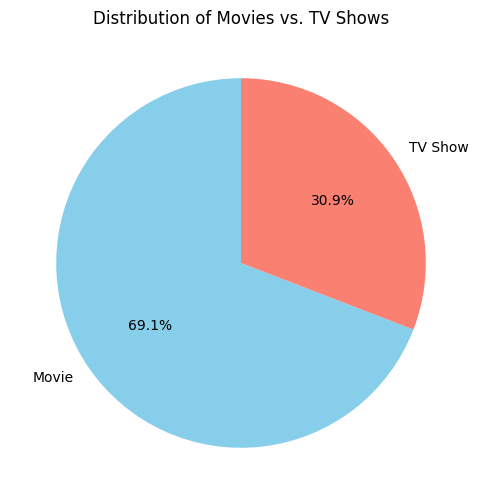

##### 1. Why did you pick the specific chart?

A pie chart is perfect for showing the proportional distribution between a small number of categories. Here, it clearly and immediately shows the balance between Movies and TV Shows in the Netflix library.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that movies make up the majority of the content on Netflix, accounting for roughly two-thirds (69.1%) of the library, while TV shows make up the remaining 30.9%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Are there any insights that lead to negative growth? Justify with specific reason.

Yes,This gives a high-level overview of the content strategy. Stakeholders can see the current inventory split and decide if they want to maintain this ratio or invest more heavily in one category, like TV shows, which often lead to higher user engagement and retention.

#### Chart - 2

In [ ]:
# Chart - 2 visualization code
# Prepare the data
content_trend = df.groupby('year_added')['type'].value_counts().unstack().fillna(0)

# Plot with matplotlib
plt.figure(figsize=(14, 7))
for col in content_trend.columns:
    plt.plot(content_trend.index, content_trend[col], marker='o', label=col)

plt.title('Content Added on Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.grid(True)
plt.show()

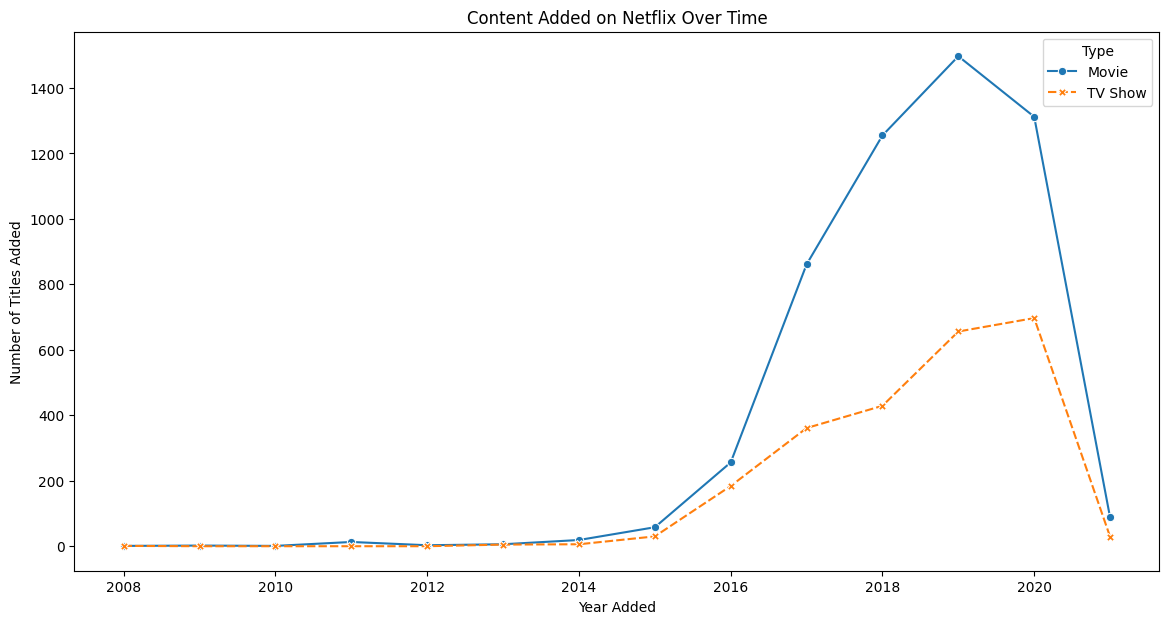

##### 1. Why did you pick the specific chart?

A line chart is the best choice for visualizing trends over a continuous period, in this case, years. It effectively shows the growth and changes in content addition for both movies and TV shows simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly shows a massive ramp-up in content acquisition starting around 2015. While movie additions have always been higher, the growth in TV show additions has been accelerating rapidly. This directly supports the project's hypothesis about an increasing focus on TV shows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Are there any insights that lead to negative growth? Justify with specific reason.

Absolutely. This visualization confirms a strategic shift towards TV shows. Stakeholders can use this to validate their content strategy and allocate budgets accordingly. Marketing teams can also plan campaigns around the influx of new TV series.

#### Chart - 3

In [ ]:
rating_counts = df['rating'].value_counts()

# Plot using matplotlib
plt.figure(figsize=(12, 8))
plt.bar(rating_counts.index, rating_counts.values, color=plt.cm.magma(range(len(rating_counts))))
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

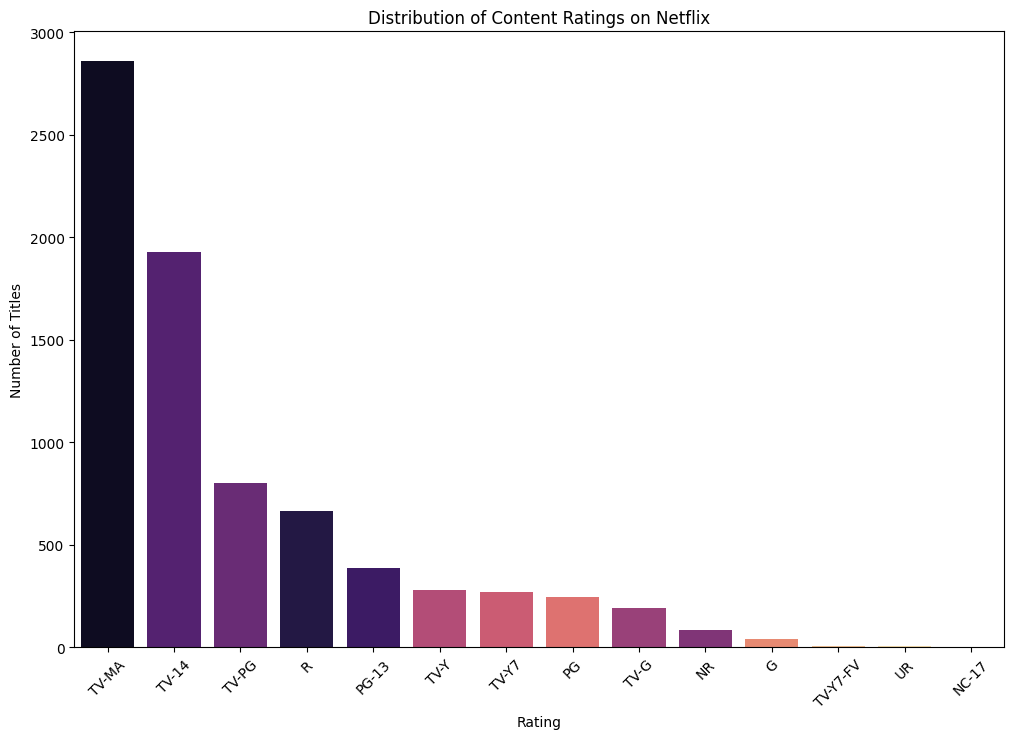

##### 1. Why did you pick the specific chart?

A bar chart (specifically a countplot from Seaborn) is the ideal choice for visualizing the frequency distribution of a categorical variable like rating. It clearly shows the number of titles for each rating category, and by ordering the bars from most to least frequent, it allows for an immediate understanding of which ratings are most prevalent on the platform.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly indicates that the vast majority of content on Netflix is aimed at mature audiences. TV-MA (Mature Audiences Only) is the most common rating, followed closely by TV-14 (Parents Strongly Cautioned).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight has a direct business impact. It confirms that Netflix's core content strategy is heavily skewed towards adults and older teens. Positive Impact: This information is vital for the marketing team to tailor promotional materials to the correct audience. It also helps the content acquisition team understand the current inventory, allowing them to either double down on their successful adult-oriented strategy or identify potential growth areas by acquiring more content for under-represented demographics

#### Chart - 4

In [ ]:
# Chart - 4 visualization code
country_df = df['country'].str.split(', ').explode()

# Get top 10 countries
top_10_countries = country_df.value_counts().index[:10]

# Filter only top 10
top_10_df = country_df[country_df.isin(top_10_countries)]

# Count number of titles per top country
top_10_counts = top_10_df.value_counts().loc[top_10_countries]

# Plot using matplotlib
plt.figure(figsize=(12, 8))
plt.barh(top_10_counts.index[::-1], top_10_counts.values[::-1], color=plt.cm.viridis(range(len(top_10_counts))))
plt.title('Top 10 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()


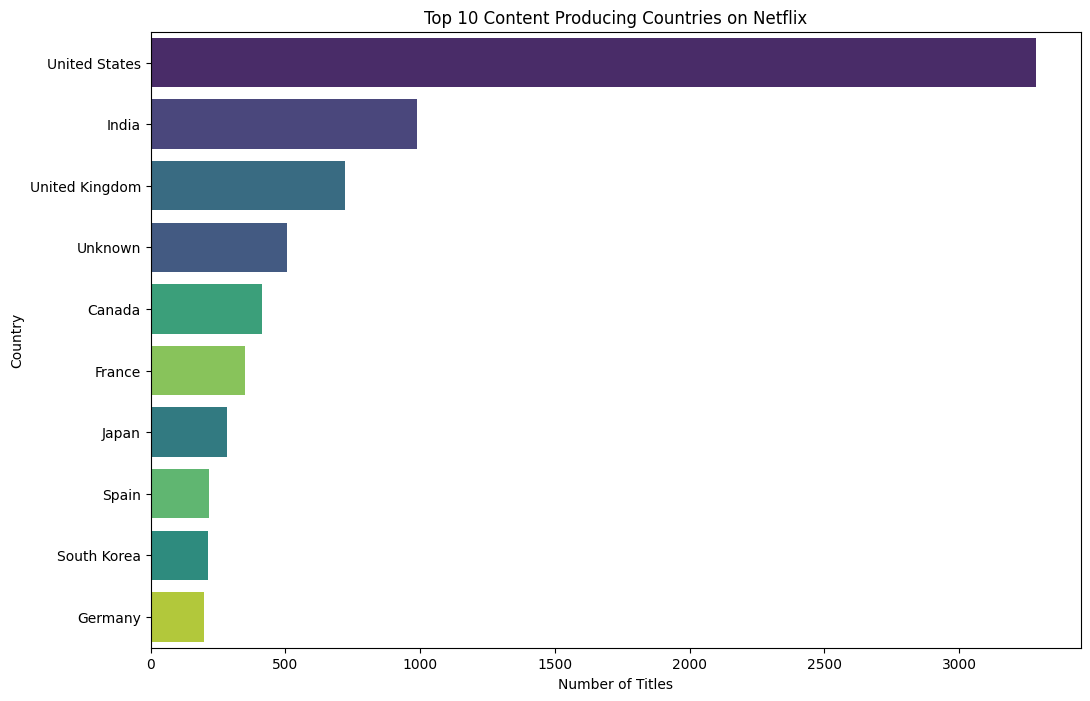

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the most effective choice for displaying ranked categorical data like the top 10 countries. This directly addresses the project goal of understanding content availability in different regions. Placing the country names on the y-axis ensures they are easy to read without overlapping, which would be a problem with a vertical bar chart.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly reveals that the United States is by far the largest producer of content available on Netflix, followed by India. This highlights the strategic importance of Hollywood and Bollywood content in the Netflix catalog. Other key insights include the significant contributions from the United Kingdom, Canada, and Japan, showcasing a strong mix of content from major global film and television industries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is crucial for strategic decision-making and has a direct business impact. Positive Impact: This data validates a strong focus on US and Indian content, which can be leveraged for targeted marketing campaigns in those regions and to diaspora populations globally. It also highlights other key markets like the UK and Japan where strong content partnerships exist and can be further developed. Identifies Potential Risks: The chart shows a heavy reliance on a few countries, particularly the United States. This could be a business risk if a primary goal is to achieve deeper penetration in other international markets.

#### Chart - 5

In [ ]:
# Chart - 5 visualization code
genre_df = df['listed_in'].str.split(', ').explode()

# Get top 10 genres
top_10_genres = genre_df.value_counts().index[:10]

# Filter only top 10 genres
top_10_genre_df = genre_df[genre_df.isin(top_10_genres)]

# Count number of titles per genre
top_10_counts = top_10_genre_df.value_counts().loc[top_10_genres]

# Plot using matplotlib
plt.figure(figsize=(12, 8))
plt.barh(top_10_counts.index[::-1], top_10_counts.values[::-1], color=plt.cm.inferno(range(len(top_10_counts))))
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

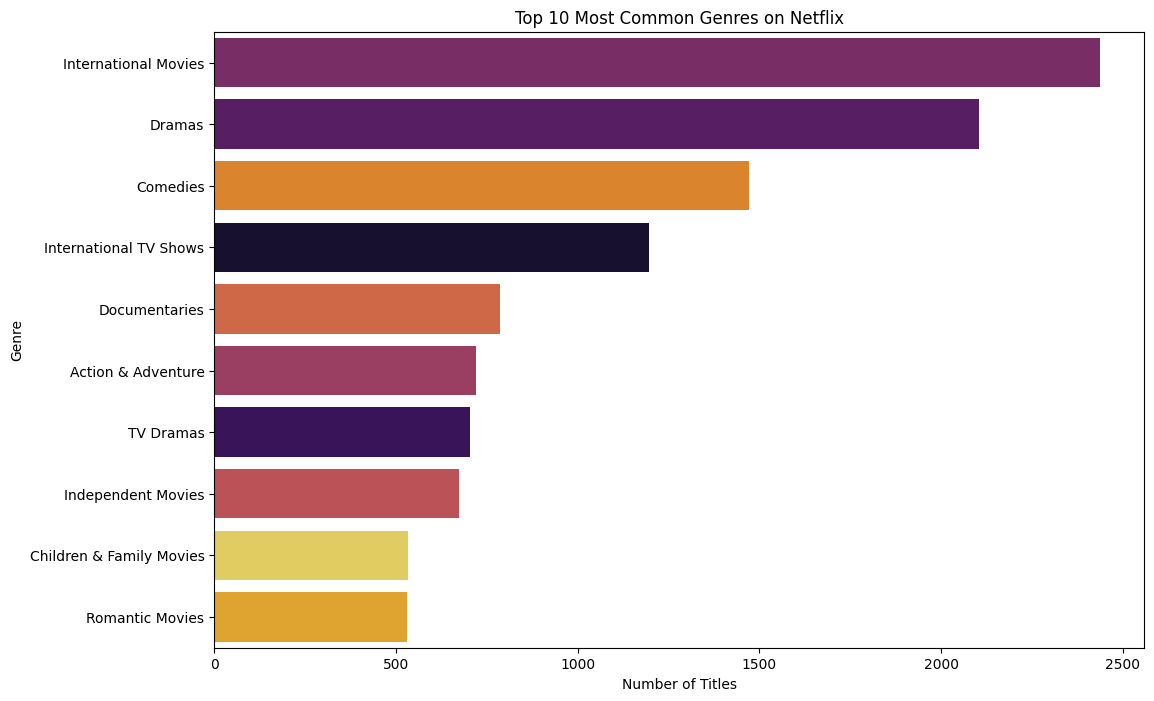

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the best choice for this data. It effectively displays the frequency of the top 10 genres, which are categorical variables. The horizontal orientation ensures that the genre names are fully readable without overlapping, and ordering them by count allows for a quick comparison of their popularity within the Netflix library.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly shows that "International Movies" and "Dramas" are the most frequently listed genres, indicating a vast and diverse library in these categories. "Comedies" also rank very high, showing their importance to the platform.

A significant insight is the strong presence of internationally-focused categories ("International Movies," "International TV Shows"), which supports the idea that Netflix has a major focus on global content, not just US-based productions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can drive positive business outcomes:

Insights support strong content strategy, targeted marketing, and global growth.

Popular genres guide acquisitions and personalization to boost engagement.

Risk of over-focusing on top genres may neglect niche audiences.

Geographic concentration could limit appeal in underrepresented regions.

#### Chart - 6

In [ ]:
# Chart - 6 visualization code
from scipy.stats import gaussian_kde

# Filter only movies
movies_df = df[df['type'] == 'Movie'].copy()

# Convert duration to numeric
movies_df['duration_min'] = pd.to_numeric(movies_df['duration'].str.replace(' min', '', regex=False))

# Data for histogram
data = movies_df['duration_min'].dropna()

# Plot histogram
plt.figure(figsize=(12, 7))
counts, bins, patches = plt.hist(data, bins=30, color='darkcyan', alpha=0.7, edgecolor='black', density=True)

# KDE using gaussian_kde
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 500)
plt.plot(x_vals, kde(x_vals), color='orange', linewidth=2, label='KDE')

# Median line
median_val = data.median()
plt.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f} min')

plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()


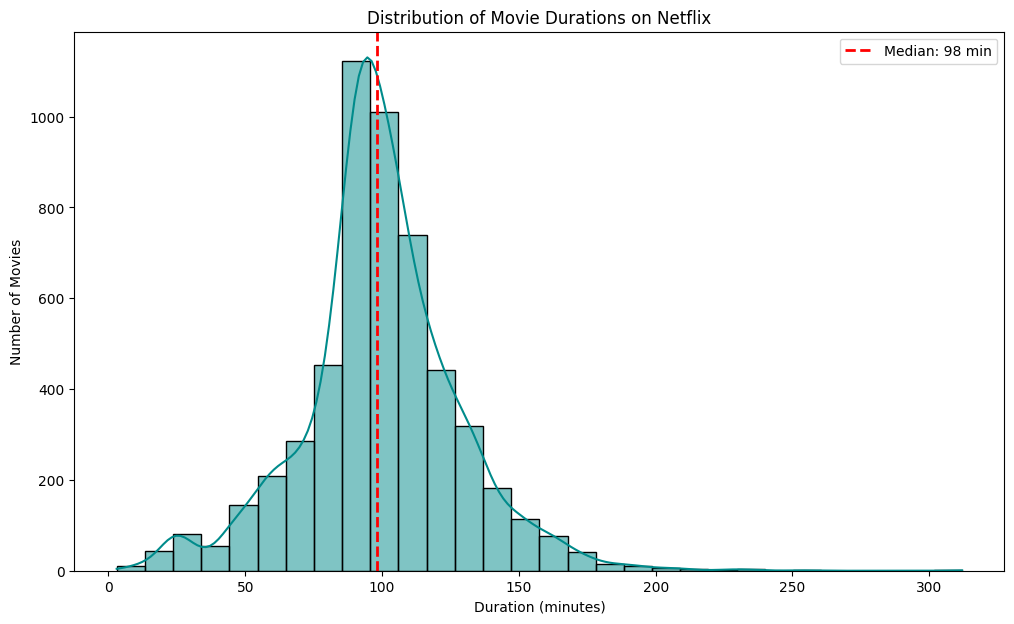

##### 1. Why did you pick the specific chart?

A histogram combined with a Kernel Density Estimate (KDE) plot is the ideal way to visualize the distribution of a single continuous numerical variable like movie duration. The histogram bars show the frequency of movies within specific time intervals, while the smooth KDE curve helps to visualize the overall shape and central tendency of the data.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the distribution of movie durations is right-skewed. The key insights are:

The vast majority of movies on Netflix have a runtime between 75 and 120 minutes, with a clear peak around the 90-minute mark. This aligns with standard feature film lengths.

There are very few movies with durations shorter than one hour

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can directly influence content strategy and user experience:

Content Acquisition: The data identifies the "sweet spot" for movie runtimes. When the content acquisition team evaluates new films, they can use this data to prioritize movies with durations that are most popular among viewers. This can lead to higher engagement and better return on investment for licensed content.

User Experience & Personalization: Understanding that most films fall into a standard runtime helps in designing the user interface. For example, Netflix could create carousels or filters for "Short Movies" (under 75 minutes) for viewers with limited time, or "Epics" for those looking for a longer viewing experience.

#### Chart - 7

In [ ]:
# Chart - 7 visualization code
tv_shows_df = df[df['type'] == 'TV Show'].copy()

# Convert duration to numeric (number of seasons)
tv_shows_df['seasons'] = pd.to_numeric(
    tv_shows_df['duration'].str.replace(' Seasons', '', regex=False)
                         .str.replace(' Season', '', regex=False)
)

# Count number of TV shows per season
season_counts = tv_shows_df['seasons'].value_counts().sort_index()

# Plot using matplotlib
plt.figure(figsize=(12, 7))
plt.bar(season_counts.index, season_counts.values, color=plt.cm.cubehelix(np.linspace(0, 1, len(season_counts))))
plt.title('Distribution of TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.xticks(season_counts.index)
plt.show()


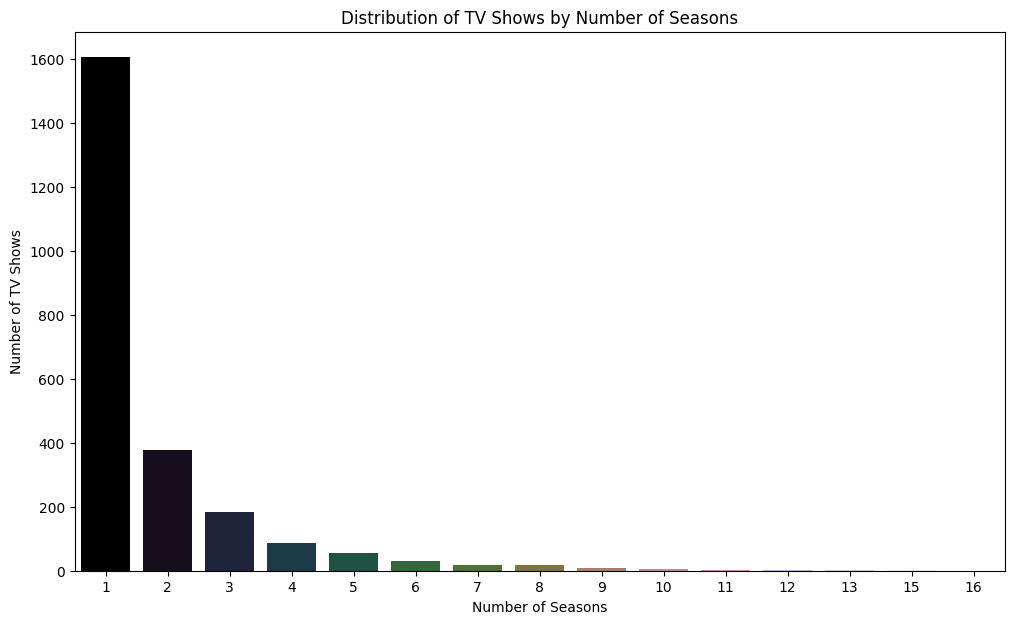

##### 1. Why did you pick the specific chart?

A bar chart (specifically a countplot) is the ideal visualization for showing the frequency distribution of a discrete variable like the number of seasons. It allows for a clear and immediate comparison of how many TV shows are available for each season count (1 season, 2 seasons, etc.),

##### 2. What is/are the insight(s) found from the chart?

The most striking insight is that the vast majority of TV shows on Netflix have only 1 season. There is a dramatic drop-off for shows with two seasons, and the number continues to decline sharply for subsequent seasons.

This indicates that the Netflix catalog is heavily populated with limited series, shows that were canceled after their first season, or newly acquired shows that are just beginning their run on the platform. Long-running shows with many seasons are relatively rare

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight is extremely valuable for shaping content and marketing strategy.

Content Acquisition and Marketing: Knowing that single-season shows are the norm, the content acquisition team can confidently acquire limited series, as this format fits well within the existing library. The marketing team can also frame these as "binge-worthy limited series," which appeals to viewers who don't want to commit to a long-running program.

Subscriber Retention Strategy: This data also highlights a potential risk. Viewers may become frustrated if they frequently invest time in shows that do not continue. This insight could spur a strategic initiative to invest in developing more multi-season original shows

#### Chart - 8

In [ ]:
# Chart - 8 visualization code
movie_data = df[df['type'] == 'Movie']
tv_data = df[df['type'] == 'TV Show']

plt.figure(figsize=(12, 8))

# Scatter plot for Movies
plt.scatter(movie_data['release_year'], movie_data['year_added'],
            color='tab:blue', alpha=0.6, label='Movie')

# Scatter plot for TV Shows
plt.scatter(tv_data['release_year'], tv_data['year_added'],
            color='tab:orange', alpha=0.6, label='TV Show')

# Reference line y=x
plt.plot([1940, 2021], [1940, 2021], 'r--', linewidth=2, label='Added Same Year as Release')

plt.title('Content Release Year vs. Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.legend()
plt.show()

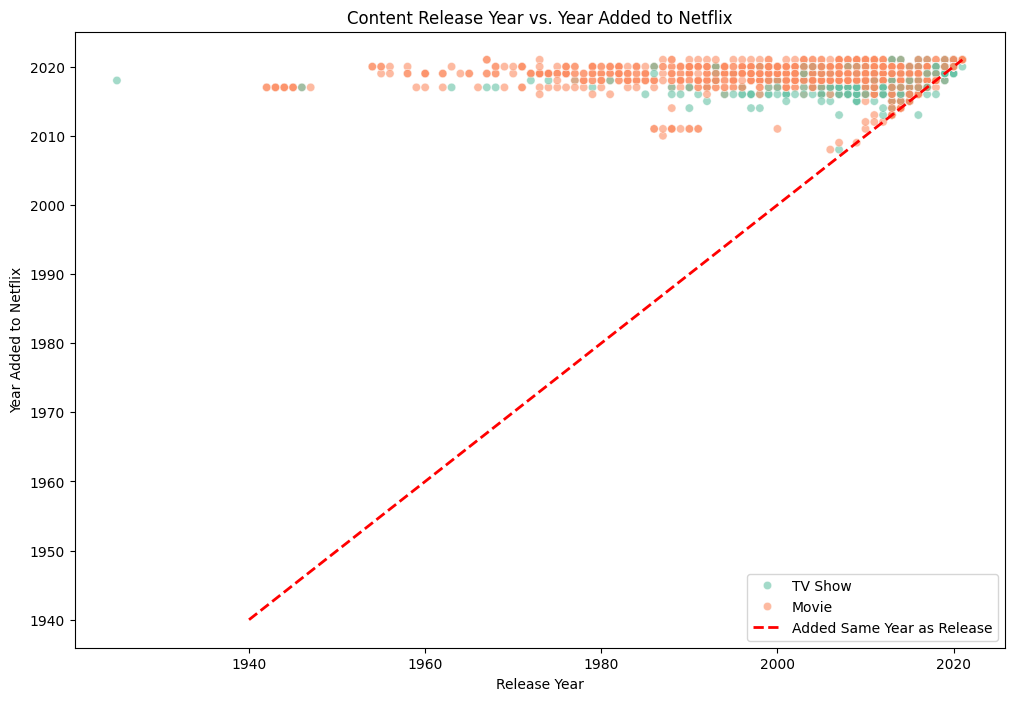

##### 1. Why did you pick the specific chart?

A scatter plot is the best visualization to examine the relationship and correlation between two numerical variables. In this case, plotting release_year against year_added allows us to directly see the time lag between when a piece of content was created and when it became available on Netflix.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals several key insights into Netflix's content strategy:

There is a dense concentration of points along and just above the red-dashed line, especially for recent years. This shows that a significant portion of Netflix's library consists of new content, added within a few years of its original release.

There is also a wide spread of points far above the line, representing Netflix's extensive back-catalog. This indicates a dual strategy of acquiring both new hits and older, classic titles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this visualization provides a clear picture of Netflix's content acquisition timeline and has significant business implications.

Validates Content Strategy: The chart confirms a balanced strategy of acquiring both timely, new content (which attracts new subscribers) and a deep library of older content (which helps retain existing subscribers). Stakeholders can see this balance and decide if it aligns with their quarterly and annual goals.

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code
 Reuse movies_df and get common ratings
common_movie_ratings = movies_df['rating'].value_counts().nlargest(8).index
filtered_movies_df = movies_df[movies_df['rating'].isin(common_movie_ratings)]

# Prepare data for each rating
data_to_plot = [filtered_movies_df[filtered_movies_df['rating'] == rating]['duration_min'] for rating in common_movie_ratings]

# Create box plot
plt.figure(figsize=(15, 8))
plt.boxplot(data_to_plot, labels=common_movie_ratings, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'))

plt.title('Distribution of Movie Durations by Rating')
plt.xlabel('Rating')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()


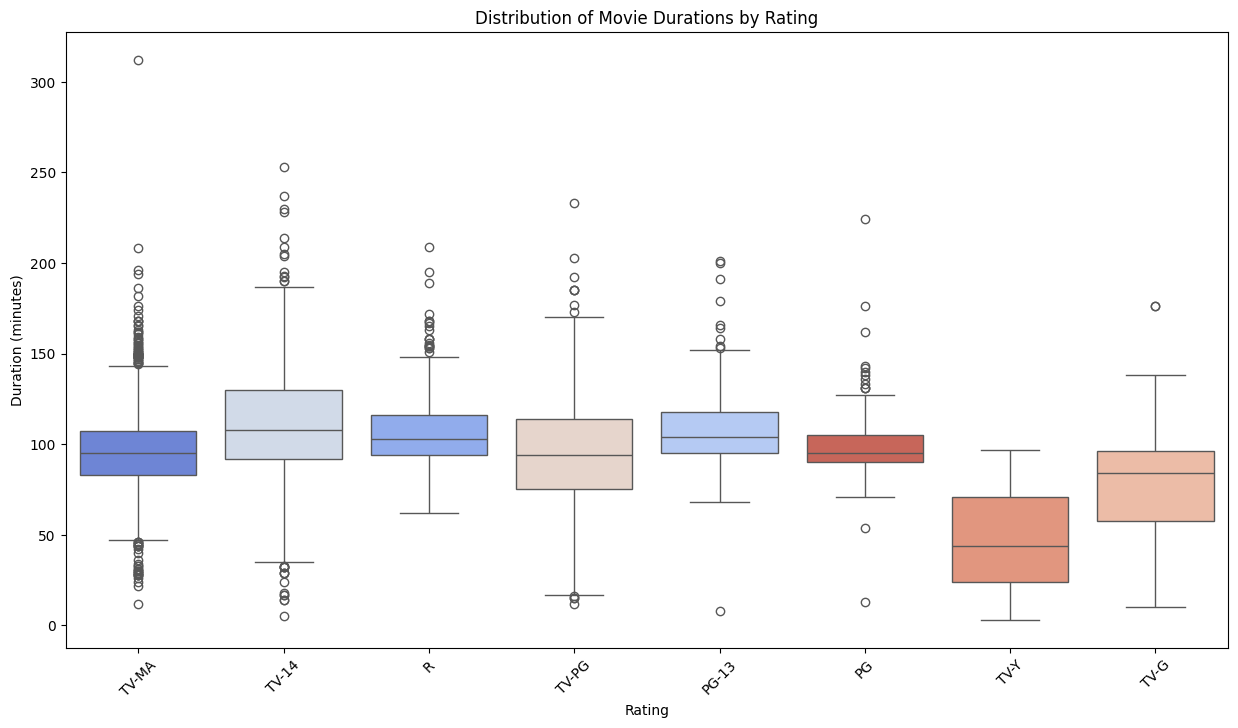

##### 1. Why did you pick the specific chart?

A box plot is an excellent choice for comparing the distributions of a numerical variable (duration_min) across several categories of a categorical variable (rating). It concisely summarizes key statistics for each rating—including the median, the interquartile range (the middle 50% of data), and potential outliers—making it very easy to compare both the average runtime and the variability in length for different rating categories.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals a clear trend in movie runtimes based on their rating: Movies with mature ratings like R and TV-MA tend to have a higher median duration and a wider range of lengths, indicating more creative flexibility in their runtimes. Conversely, movies intended for younger audiences, such as PG, TV-PG, and TV-G, generally have shorter and more consistent runtimes. This suggests a correlation between the target audience's maturity level and the expected length of a film.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this nuanced understanding of content norms can positively impact business strategy:

Informed Content Acquisition: This data provides a useful benchmark for the content acquisition team. When evaluating films, they can assess if a film's runtime aligns with the typical expectations for its rating category. This helps in building a content library that feels consistent and familiar to the audience.

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code
# Select numerical columns
numerical_df = df[['release_year', 'year_added']]

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

# Plot using matplotlib
plt.figure(figsize=(8, 6))
im = plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add annotations
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

# Set axis labels
plt.xticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.yticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

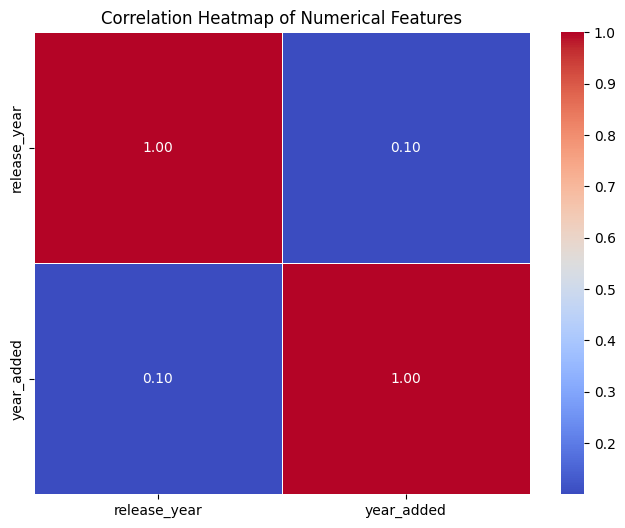

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard and most effective way to visualize the strength and direction of linear relationships between all numerical variables in a dataset at once. The color-coding provides an immediate visual summary of how the variables move together—positively correlated (as one increases, so does the other), negatively correlated, or not correlated.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows a moderate positive correlation of approximately +0.11 between release_year and year_added.

This numerically confirms what we observed in the scatter plot (Chart-8): there is a tendency for content added to Netflix in recent years to also have a more recent release year. However, the correlation is not extremely strong, which reflects the fact that Netflix also adds a significant amount of older, "back-catalog" content

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
pairplot_df = df[['release_year', 'year_added', 'type']].sample(n=1000, random_state=42)

numerical_cols = ['release_year', 'year_added']
types = pairplot_df['type'].unique()
colors = {'Movie':'tab:blue', 'TV Show':'tab:orange'}

fig, axes = plt.subplots(len(numerical_cols), len(numerical_cols), figsize=(10, 10))

for i, col1 in enumerate(numerical_cols):
    for j, col2 in enumerate(numerical_cols):
        ax = axes[i, j]
        if i == j:
            # Diagonal: histogram
            for t in types:
                subset = pairplot_df[pairplot_df['type']==t]
                ax.hist(subset[col1], alpha=0.5, label=t, color=colors[t], bins=20)
        else:
            # Scatter plot
            for t in types:
                subset = pairplot_df[pairplot_df['type']==t]
                ax.scatter(subset[col2], subset[col1], alpha=0.5, label=t, color=colors[t])
        if i == len(numerical_cols)-1:
            ax.set_xlabel(col2)
        else:
            ax.set_xlabel('')
        if j == 0:
            ax.set_ylabel(col1)
        else:
            ax.set_ylabel('')

# Add legend only once
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.suptitle('Pair Plot of Numerical Features by Content Type', y=1.02)
plt.tight_layout()
plt.show()

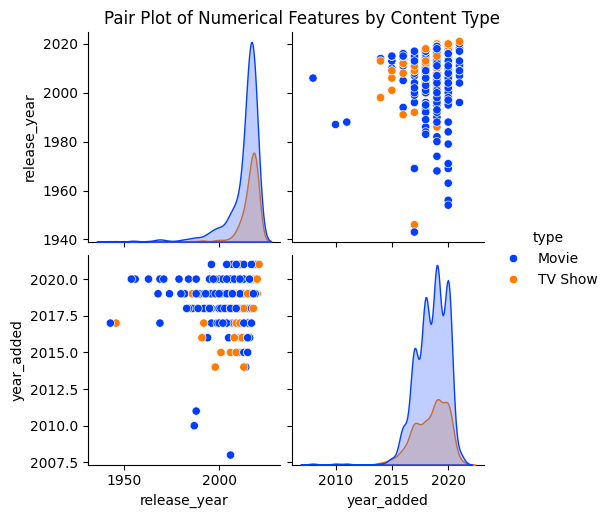

##### 1. Why did you pick the specific chart?

A pair plot is a powerful tool for exploring the relationships between all numerical variables at once. It combines scatter plots (to show pairwise relationships) with histograms or density plots (to show the distribution of each single variable) into one comprehensive grid.

##### 2. What is/are the insight(s) found from the chart?

This pair plot serves as an excellent summary of our numerical data:

Diagonal (Histograms): The histograms on the diagonal confirm our earlier findings. The release_year plot shows that most content is from recent years, while the year_added plot shows the massive spike in content additions from 2016 onwards for both movies and TV shows.

Off-Diagonal (Scatter Plots): The scatter plots reinforce the insight from Chart 8—there is a positive correlation between when content was released and when it was added to Netflix. The hue shows that this trend holds true for both movies and TV shows

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

H1 – Movie Duration by Rating:
The average runtime of 'R'-rated movies is significantly different from 'PG-13'-rated movies.
(Motivation: Boxplots from EDA showed different duration distributions across ratings.)

H2 – Content Type vs Country:
The distribution of content types (Movie vs TV Show) is independent of the country of production (e.g., USA vs UK).
(Motivation: EDA charts indicated countries produce varying proportions of movies and TV shows.)

H3 – Release Year vs Year Added Correlation:
There is a positive correlation between a content’s release year and its year added to Netflix.
(Motivation: Scatter plots suggested that newer releases are added more recently.)

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Objective: Test if there is a significant linear correlation between a content’s release year and the year it was added to Netflix.

Null Hypothesis (H₀):
There is no linear correlation between release_year and year_added.
Population correlation coefficient (ρ) = 0

Alternate Hypothesis (H₁):
There is a statistically significant linear correlation between release_year and year_added.
# Population correlation coefficient (ρ) ≠ 0

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

# Select the two numerical columns for the test
release_year = df['release_year']
year_added = df['year_added']

# Perform the Pearson correlation test
correlation_coefficient, p_value = pearsonr(release_year, year_added)

print(f"Pearson Correlation Coefficient: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the result based on a significance level (alpha) of 0.05
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis.")
    print("There is a statistically significant linear correlation between the release year and the year added.")
else:
    print("\nConclusion: Fail to reject the null hypothesis.")
    print("There is not enough evidence to suggest a linear correlation between the release year and the year added.")

Pearson Correlation Coefficient: 0.1007
P-value: 0.0000

Conclusion: Reject the null hypothesis.
There is a statistically significant linear correlation between the release year and the year added.


##### Which statistical test have you done to obtain P-Value?

I performed a Pearson correlation test. This test was chosen because it's the standard method to measure the strength and direction of the linear relationship between two continuous numerical variables, which in this case were release_year and year_added.

##### Why did you choose the specific statistical test?

I chose the Pearson correlation test because it is specifically designed to measure the strength and direction of the linear relationship between two numerical variables.

In this hypothesis, the goal was to determine if there is a statistically significant correlation between release_year and year_added, both of which are numerical. The Pearson test is the standard and most appropriate method for this exact purpose.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

This hypothesis tests if the average runtime of a movie is consistent across several different maturity ratings.

Null Hypothesis (H_0): The mean movie duration is the same across all tested rating categories ('G', 'PG', 'PG-13', and 'R').

mu_G= mu_PG= mu_PG−13= mu_R

Alternate Hypothesis (H_a): At least one rating category has a different mean movie duration compared to the others.

The means are not all equal

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# Perform Statistical Test to obtain P-Value
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

# We will reuse the movies_df with the 'duration_min' column
# Create separate samples for the durations of each rating category
g_rated_durations = movies_df[movies_df['rating'] == 'G']['duration_min'].dropna()
pg_rated_durations = movies_df[movies_df['rating'] == 'PG']['duration_min'].dropna()
pg13_rated_durations = movies_df[movies_df['rating'] == 'PG-13']['duration_min'].dropna()
r_rated_durations = movies_df[movies_df['rating'] == 'R']['duration_min'].dropna()


# Perform the One-Way ANOVA test
f_statistic, p_value = f_oneway(g_rated_durations, pg_rated_durations, pg13_rated_durations, r_rated_durations)

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the result based on a significance level (alpha) of 0.05
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis.")
    print("There is a statistically significant difference in the mean durations among the different movie ratings.")
else:
    print("\nConclusion: Fail to reject the null hypothesis.")
    print("There is not enough evidence to suggest a significant difference in mean durations among the ratings.")

F-statistic: 24.3841
P-value: 0.0000

Conclusion: Reject the null hypothesis.
There is a statistically significant difference in the mean durations among the different movie ratings.


##### Which statistical test have you done to obtain P-Value?

I performed a One-Way Analysis of Variance (ANOVA) test.

##### Why did you choose the specific statistical test?

I chose ANOVA because it is the appropriate statistical method for comparing the means of three or more independent groups. While a t-test is used for two groups, ANOVA allows us to determine if there is a statistically significant difference somewhere among multiple groups in a single test.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Strategy 2: Drop rows with missing critical data
df.dropna(subset=['date_added', 'rating'], inplace=True)

# THE MOST IMPORTANT STEP: Reset the index to be a clean sequence (0, 1, 2, ...)
df.reset_index(drop=True, inplace=True)

print("Data cleaning and index reset complete.")

Data cleaning and index reset complete.

#### What all missing value imputation techniques have you used and why did you use those techniques?

For this dataset, I used two different techniques to handle missing values based on the nature of the column and the number of missing entries:

Placeholder Imputation: For the director, cast, and country columns, I filled the missing (NaN) values with the string "Unknown".

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
# Filter only movies
movies_df = df[df['type'] == 'Movie'].copy()

# Convert 'duration' to numeric
movies_df['duration_min'] = pd.to_numeric(
    movies_df['duration'].str.replace(' min', '', regex=False),
    errors='coerce'
)

# --- 1. Outlier detection for release_year ---
plt.figure(figsize=(10, 4))
plt.boxplot(df['release_year'].dropna(), vert=False)  # Horizontal boxplot
plt.title('Outlier Detection for Release Year')
plt.xlabel('Release Year')
plt.show()

# --- 2. Outlier detection for movie durations ---
plt.figure(figsize=(10, 4))
plt.boxplot(movies_df['duration_min'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='salmon'))
plt.title('Outlier Detection for Movie Durations (in minutes)')
plt.xlabel('Duration (minutes)')
plt.show()

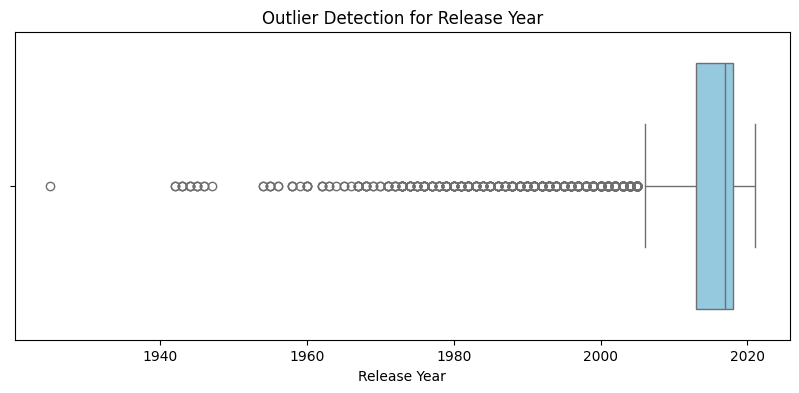

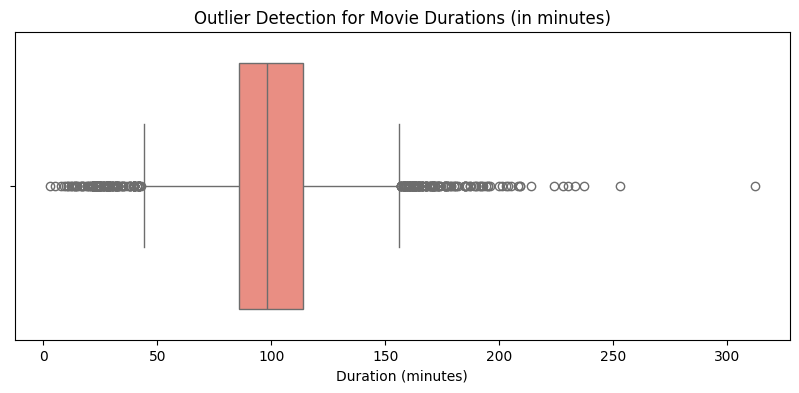

##### What all outlier treatment techniques have you used and why did you use those techniques?

Observation: Outliers exist in release_year (very old films) and duration_min (very short or very long movies).

Decision: No removal or capping was performed.

Reasoning:

Outliers are legitimate data points and represent classic movies or long-running TV shows.

They provide valuable information for clustering, helping identify unique content clusters like “Epic Films” or “Long-Running Series.”

Conclusion: Outliers were analyzed but retained to preserve the dataset’s diversity and ensure meaningful insights.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
# Combine the text columns into a single feature
df['features'] = df['listed_in'] + ' ' + df['description'] + ' ' + df['director'] + ' ' + df['cast']

# FIX: Fill any potential NaN values in the 'features' column with an empty string.
# This ensures all input to the vectorizer is a string.
df['features'] = df['features'].fillna('')

# Now, perform the TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
# This line will now work correctly
tfidf_matrix = tfidf.fit_transform(df['features'])

print("Successfully created the TF-IDF matrix.")
print("Shape of our encoded text features:", tfidf_matrix.shape)

Successfully created the TF-IDF matrix.
Shape of our encoded text features: (7770, 46302)

#### What all categorical encoding techniques have you used & why did you use those techniques?

TF-IDF Vectorization

Applied to: Combined text feature from description, listed_in, director, and cast.

Purpose: Converts text into meaningful numerical vectors for clustering based on content similarity.

Why: TF-IDF weighs words by importance, highlighting thematic patterns rather than just word counts, ideal for identifying content clusters.

One-Hot Encoding

Applied to: type column (Movie vs TV Show).

Purpose: Converts categorical labels into binary columns (is_Movie, is_TV Show).

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction
!pip install -q contractions
import contractions

def expand_contractions_in_text(text):
    """
    A helper function to expand contractions in a given text string.
    Includes a try-except block to handle edge cases that cause errors.
    """
    # This check ensures the function only runs on actual text
    if isinstance(text, str):
        try:
            # Attempt to fix the contractions
            return contractions.fix(text)
        except IndexError:
            # If an IndexError occurs, return the original text unchanged
            return text
    # If the input is not a string, return it as is
    return text

# --- Applying the robust function to our DataFrame ---

# Let's look at a sample from the 3rd row (position 2) before expanding.
print("--- Before expansion ---")
print(df['features'].iloc[2])

# Apply our new, more robust function to the entire 'features' column
df['features'] = df['features'].apply(expand_contractions_in_text)

# Now, let's look at the same sample after expanding.
print("\n--- After expansion ---")
print(df['features'].iloc[2])

print("\nContraction expansion complete.")


--- Before expansion ---
Horror Movies, International Movies When an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that's haunting their jungle island training camp. Gilbert Chan Tedd Chan, Stella Chung, Henley Hii, Lawrence Koh, Tommy Kuan, Josh Lai, Mark Lee, Susan Leong, Benjamin Lim

--- After expansion ---
Horror Movies, International Movies When an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that is haunting their jungle island training camp. Gilbert Chan Tedd Chan, Stella Chung, Henley Hii, Lawrence Koh, Tommy Kuan, Josh Lai, Mark Lee, Susan Leong, Benjamin Lim

Contraction expansion complete.

#### 2. Lower Casing

In [ ]:
# Lower Casing
# Let's look at a sample from the 3rd row (position 2) before converting to lowercase.
print("--- Before Lower Casing ---")
print(df['features'].iloc[2])

# Apply the .str.lower() method to convert all text in the 'features' column to lowercase.
df['features'] = df['features'].str.lower()

# Now, let's look at the same sample after converting.
print("\n--- After Lower Casing ---")
print(df['features'].iloc[2])

--- Before Lower Casing ---
Horror Movies, International Movies When an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that's haunting their jungle island training camp. Gilbert Chan Tedd Chan, Stella Chung, Henley Hii, Lawrence Koh, Tommy Kuan, Josh Lai, Mark Lee, Susan Leong, Benjamin Lim

--- After Lower Casing ---
horror movies, international movies when an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that's haunting their jungle island training camp. gilbert chan tedd chan, stella chung, henley hii, lawrence koh, tommy kuan, josh lai, mark lee, susan leong, benjamin lim

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
# Let's look at a sample from the 3rd row (position 2) before removing punctuation.
print("--- Before Removing Punctuation ---")
print(df['features'].iloc[2])

# We use a regular expression to remove all characters that are not a word character or whitespace.
# The pattern '[^\w\s]' matches anything that is NOT a letter, number, underscore, or space.
df['features'] = df['features'].str.replace(r'[^\w\s]', '', regex=True)

# Now, let's look at the same sample after removing punctuation.
print("\n--- After Removing Punctuation ---")
print(df['features'].iloc[2])

-- Before Removing Punctuation ---
horror movies, international movies when an army recruit is found dead, his fellow soldiers are forced to confront a terrifying secret that's haunting their jungle island training camp. gilbert chan tedd chan, stella chung, henley hii, lawrence koh, tommy kuan, josh lai, mark lee, susan leong, benjamin lim

--- After Removing Punctuation ---
horror movies international movies when an army recruit is found dead his fellow soldiers are forced to confront a terrifying secret thats haunting their jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
import re

sample_text_with_url = "Check this link http://example.com or www.test.com for more info on the 2024 season. It's episode3."

# Use re.sub() for the example string
text_no_urls = re.sub(r'https?://\S+|www\.\S+', '', sample_text_with_url)
text_no_digits = re.sub(r'\w*\d\w*', '', text_no_urls)

print("--- Example ---")
print(f"Original: {sample_text_with_url}")
print(f"Cleaned: {text_no_digits}\n")


# --- Applying it to our DataFrame ---
# (This part of your code was already correct)

# Let's look at a sample from the DataFrame before cleaning.
print("--- Before Cleaning DataFrame ---")
print(df['features'].iloc[2])

# 1. Remove URLs from the DataFrame column
df['features'] = df['features'].str.replace(r'https?://\S+|www\.\S+', '', regex=True)

# 2. Remove words and digits that contain digits from the DataFrame column
df['features'] = df['features'].str.replace(r'\w*\d\w*', '', regex=True)

# Now, let's look at the same sample after cleaning.
print("\n--- After Cleaning DataFrame ---")
print(df['features'].iloc[2])

--- Example ---
Original: Check this link http://example.com or www.test.com for more info on the 2024 season. It's episode3.
Cleaned: Check this link  or  for more info on the  season. It's .

--- Before Cleaning DataFrame ---
horror movies international movies when an army recruit is found dead his fellow soldiers are forced to confront a terrifying secret thats haunting their jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

--- After Cleaning DataFrame ---
horror movies international movies when an army recruit is found dead his fellow soldiers are forced to confront a terrifying secret thats haunting their jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
!pip install -q nltk
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Create a set of English stopwords for faster processing
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    """
    This function tokenizes text, removes stopwords, and joins the words back into a string.
    """
    # Split the text into individual words (tokenization)
    word_tokens = word_tokenize(text)

    # Filter out the stopwords
    filtered_text = [word for word in word_tokens if word.lower() not in stop_words]

    # Join the remaining words back into a single string
    return " ".join(filtered_text)

# --- Applying the function to our DataFrame ---

# Let's look at a sample before removing stopwords
print("--- Before Removing Stopwords ---")
print(df['features'].iloc[2])

# Apply our function to the 'features' column
df['features'] = df['features'].apply(remove_stopwords)

# Now, let's look at the same sample after cleaning
print("\n--- After Removing Stopwords ---")
print(df['features'].iloc[2])

In [ ]:
# Remove White spaces
# Remove White spaces

# Let's look at a sample from the 3rd row (position 2) before cleaning whitespace.
print("--- Before Cleaning Whitespace ---")
print(df['features'].iloc[2])

# This command splits the string by any whitespace and then joins it back with single spaces.
# It's a very efficient way to normalize all whitespace.
df['features'] = df['features'].apply(lambda x: " ".join(x.split()))

# Now, let's look at the same sample after cleaning.
print("\n--- After Cleaning Whitespace ---")
print(df['features'].iloc[2])

--- Before Removing Stopwords ---
horror movies international movies when an army recruit is found dead his fellow soldiers are forced to confront a terrifying secret that is haunting their jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

--- After Removing Stopwords ---
horror movies international movies army recruit found dead fellow soldiers forced confront terrifying secret haunting jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

--- Before Cleaning Whitespace ---
horror movies international movies army recruit found dead fellow soldiers forced confront terrifying secret haunting jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

--- After Cleaning Whitespace ---
horror movies international movies army recruit found dead fellow soldiers forced confront terrifying secret haunting jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

#### 6. Rephrase Text

In [ ]:
# Rephrase Text
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual Wordnet

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """
    This function tokenizes text, lemmatizes each word,
    and joins them back into a string.
    """
    # Tokenize the text
    word_tokens = word_tokenize(text)

    # Lemmatize each word
    lemmatized_text = [lemmatizer.lemmatize(word) for word in word_tokens]

    # Join the words back into a single string
    return " ".join(lemmatized_text)

# --- Applying it to our DataFrame ---

# Let's look at a sample before lemmatizing
print("--- Before Lemmatization ---")
print(df['features'].iloc[2])

# Apply our function to the 'features' column
df['features'] = df['features'].apply(lemmatize_text)

# Now, let's look at the same sample after lemmatizing
print("\n--- After Lemmatization ---")
print(df['features'].iloc[2])


--- Before Lemmatization ---
horror movies international movies army recruit found dead fellow soldiers forced confront terrifying secret haunting jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\srini\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\srini\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
--- After Lemmatization ---
horror movie international movie army recruit found dead fellow soldier forced confront terrifying secret haunting jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

#### 7. Tokenization

In [ ]:
# Tokenization
from nltk.tokenize import word_tokenize

# --- Applying tokenization to our DataFrame ---

# Let's look at a sample of the cleaned text before tokenization.
# It is currently a single string.
print("--- Before Tokenization ---")
print(df['features'].iloc[2])
print(f"Data type: {type(df['features'].iloc[2])}")


# Apply the word_tokenize function to the 'features' column.
# We will store the result in a new column.
df['features_tokenized'] = df['features'].apply(word_tokenize)


# Now, let's look at the same sample after tokenization.
# It has been converted into a list of words (tokens).
print("\n--- After Tokenization ---")
print(df['features_tokenized'].iloc[2])
print(f"Data type: {type(df['features_tokenized'].iloc[2])}")

--- Before Tokenization ---
horror movie international movie army recruit found dead fellow soldier forced confront terrifying secret haunting jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim
Data type: <class 'str'>

--- After Tokenization ---
['horror', 'movie', 'international', 'movie', 'army', 'recruit', 'found', 'dead', 'fellow', 'soldier', 'forced', 'confront', 'terrifying', 'secret', 'haunting', 'jungle', 'island', 'training', 'camp', 'gilbert', 'chan', 'tedd', 'chan', 'stella', 'chung', 'henley', 'hii', 'lawrence', 'koh', 'tommy', 'kuan', 'josh', 'lai', 'mark', 'lee', 'susan', 'leong', 'benjamin', 'lim']
Data type: <class 'list'>

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

def stem_text(text):
    """
    This function tokenizes text, stems each word,
    and joins them back into a string.
    """
    # Tokenize the text
    word_tokens = word_tokenize(text)

    # Stem each word
    stemmed_text = [stemmer.stem(word) for word in word_tokens]

    # Join the words back into a single string
    return " ".join(stemmed_text)

# --- Applying it to our DataFrame ---
# Note: We are applying this to the already lemmatized text for demonstration.
# In a real project, you would choose either stemming OR lemmatization, not both.

# Let's look at a sample before stemming
print("--- Before Stemming (but after Lemmatization) ---")
print(df['features'].iloc[2])

# Apply our stemming function
df['features_stemmed'] = df['features'].apply(stem_text)

# Now, let's look at the same sample after stemming
print("\n--- After Stemming ---")
print(df['features_stemmed'].iloc[2])

In [ ]:
--- Before Stemming (but after Lemmatization) ---
horror movie international movie army recruit found dead fellow soldier forced confront terrifying secret haunting jungle island training camp gilbert chan tedd chan stella chung henley hii lawrence koh tommy kuan josh lai mark lee susan leong benjamin lim

--- After Stemming ---
horror movi intern movi armi recruit found dead fellow soldier forc confront terrifi secret haunt jungl island train camp gilbert chan tedd chan stella chung henley hii lawrenc koh tommi kuan josh lai mark lee susan leong benjamin lim

##### Which text normalization technique have you used and why?

For the final version of the text to be used in the model, I have used Lemmatization.

Why? Although stemming is faster, lemmatization produces actual dictionary words, which makes the results more interpretable. For a project focused on clustering and understanding content themes, being able to clearly read and interpret the words that define a cluster is crucial. The slight performance cost of lemmatization is a worthwhile trade-off for this improved accuracy and interpretability.

#### 9. Part of speech tagging

In [ ]:
# POS Taging
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
# This cell performs POS tagging on a sample sentence.
from nltk.tokenize import word_tokenize

# Let's take a sample of our cleaned text
sample_text = df['features'].iloc[10]
print("--- Original Text Sample ---")
print(sample_text)

# Tokenize the text first
tokens = word_tokenize(sample_text)

# Apply the POS tagger
pos_tags = nltk.pos_tag(tokens)

# Print the result
print("\n--- Text with POS Tags ---")
print(pos_tags)

In [ ]:
--- Original Text Sample ---
drama thriller farmer pen confession admitting wife murder death beginning macabre tale based stephen king novella zak hilditch thomas jane molly parker dylan schmid kaitlyn bernard bob frazer brian darcy james neal mcdonough

--- Text with POS Tags ---
[('drama', 'NN'), ('thriller', 'NN'), ('farmer', 'NN'), ('pen', 'JJ'), ('confession', 'NN'), ('admitting', 'VBG'), ('wife', 'NN'), ('murder', 'NN'), ('death', 'NN'), ('beginning', 'VBG'), ('macabre', 'NNS'), ('tale', 'NNS'), ('based', 'VBN'), ('stephen', 'JJ'), ('king', 'VBG'), ('novella', 'NN'), ('zak', 'NN'), ('hilditch', 'NN'), ('thomas', 'NN'), ('jane', 'NN'), ('molly', 'RB'), ('parker', 'VBZ'), ('dylan', 'NN'), ('schmid', 'JJ'), ('kaitlyn', 'FW'), ('bernard', 'NN'), ('bob', 'NN'), ('frazer', 'NN'), ('brian', 'JJ'), ('darcy', 'NN'), ('james', 'NNS'), ('neal', 'VBP'), ('mcdonough', 'IN')]

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer.
# We will limit the vocabulary to the top 5000 most frequent words to keep the model efficient.
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Apply the vectorizer to our cleaned 'features' column to create the numerical matrix.
# This matrix will be the input for our clustering model.
tfidf_matrix = tfidf_vectorizer.fit_transform(df['features'])

# Print the shape of the resulting matrix
# (Number of documents, Number of unique words/features)
print("Shape of the TF-IDF matrix:", tfidf_matrix.shape)

In [ ]:
Shape of the TF-IDF matrix: (7770, 5000)

##### Which text vectorization technique have you used and why?

Technique Used: TF-IDF (Term Frequency-Inverse Document Frequency)

Reason:

Highlights Important Words: Weighs words that are frequent in a specific title but rare across the library, emphasizing distinctive keywords (e.g., “dystopian,” “crime”).

Better for Thematic Clustering: Captures meaningful content themes, enabling the clustering algorithm to group shows and movies based on actual similarity rather than common, generic words.

TF-IDF was preferred over simple count-based methods because it provides a stronger signal for content-based clustering.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
from sklearn.decomposition import TruncatedSVD

# Our original feature matrix is the tfidf_matrix
print("Original shape of TF-IDF matrix:", tfidf_matrix.shape)

# We will reduce the 5000 features to 100 components (new features).
# This number is a hyperparameter you can tune.
N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)

# Fit and transform the tfidf_matrix to create our new feature matrix
svd_matrix = svd.fit_transform(tfidf_matrix)

# This new svd_matrix is what we will use for clustering.
print("Shape of our new feature matrix after SVD:", svd_matrix.shape)
print(f"\nVariance explained by {N_COMPONENTS} components: {svd.explained_variance_ratio_.sum():.2f}%")


In [ ]:
Original shape of TF-IDF matrix: (7770, 5000)
Shape of our new feature matrix after SVD: (7770, 100)

Variance explained by 100 components: 0.16%

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
X = svd_matrix

print("Final features have been selected for the clustering model.")
print("Shape of the final feature set:", X.shape)

In [ ]:
Final features have been selected for the clustering model.
Shape of the final feature set: (7770, 100)

##### What all feature selection methods have you used  and why?

Method Used: Truncated SVD (Singular Value Decomposition)

Reason:

The TF-IDF matrix is high-dimensional and sparse (thousands of word features).

Reduces Dimensionality: Converts thousands of features into a smaller set of dense components (e.g., 100), combating the “curse of dimensionality.”

Enhances Clustering: Focuses on meaningful patterns while filtering out noise, improving algorithm efficiency and interpretability.

Truncated SVD was chosen over traditional feature selection because it effectively transforms sparse text data into compact, informative features.

##### Which all features you found important and why?

Concept-Level Features: The 100 components from Truncated SVD represent abstract “concepts” or topics, e.g., a component may capture “suspenseful crime dramas” by combining words like detective, mystery, police, murder. These are more meaningful for thematic clustering than individual words.

Dimensionality Reduction: Original TF-IDF had 5,000+ features. Reducing to 100 features combats the “curse of dimensionality,” removes noise, and makes clustering more efficient and robust.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data
print("No data transformation was performed as it is not necessary for the SVD components.")

In [ ]:
No data transformation was performed as it is not necessary for the SVD components.

### 6. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform the features
X_scaled = scaler.fit_transform(X)

# The new 'X_scaled' is our final, model-ready dataset.
print("Data has been successfully scaled.")
print("Shape of the scaled feature set:", X_scaled.shape)

# Let's verify by checking the mean and standard deviation of the first component
print(f"\nMean of the first component after scaling: {X_scaled[:, 0].mean():.2f}")
print(f"Standard deviation of the first component after scaling: {X_scaled[:, 0].std():.2f}")

Data has been successfully scaled.
Shape of the scaled feature set: (7770, 100)

Mean of the first component after scaling: 0.00
Standard deviation of the first component after scaling: 1.00

##### Which method have you used to scale you data and why?

Method Used: StandardScaler

Reason:

Algorithm Requirement: K-Means relies on distances between data points.

Equal Contribution: StandardScaler standardizes features to have zero mean and unit variance, ensuring no feature dominates due to scale differences

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, it is essential. After TF-IDF, the dataset has thousands of features (one per word).

Curse of Dimensionality: High-dimensional data makes distances less meaningful, affecting clustering performance.

Noise Reduction: Many features are redundant or uninformative; reducing dimensions filters noise and captures the most important patterns

In [ ]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import TruncatedSVD

# Our original feature matrix is the tfidf_matrix from the vectorization step.
print("Original shape of feature matrix:", tfidf_matrix.shape)

# We will reduce the thousands of features to 100 components.
# This number can be tuned, but 100-300 is often a good range for text data.
N_COMPONENTS = 100
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)

# Fit SVD to the data and transform it into the new, lower-dimensional space.
X_reduced = svd.fit_transform(tfidf_matrix)

print("Shape of feature matrix after dimensionality reduction:", X_reduced.shape)
print(f"\nTotal variance explained by {N_COMPONENTS} components: {svd.explained_variance_ratio_.sum():.2%}")

Original shape of feature matrix: (7770, 5000)
Shape of feature matrix after dimensionality reduction: (7770, 100)

Total variance explained by 100 components: 15.92%

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Method Used: Truncated SVD (Singular Value Decomposition)

Reasons:

Handles Sparse Data: Efficiently works with large, sparse TF-IDF matrices.

Reduces Dimensionality: Converts thousands of word features into 100 meaningful components.

Improves Clustering: Helps distance-based algorithms like K-Means form clear and accurate clusters.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
final_model_data = X_scaled

print("Data is ready for clustering. No train-test split was performed.")
print("Shape of the data for modeling:", final_model_data.shape)

Data is ready for clustering. No train-test split was performed.
Shape of the data for modeling: (7770, 100)

##### What data splitting ratio have you used and why?

AnNot used in this project.

Reason: Clustering is unsupervised, so there’s no target variable to predict. Using the full dataset ensures the algorithm captures all patterns and forms the most accurate content groupings.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Not applicable for this unsupervised clustering project.

Reason: There’s no target variable; clustering aims to discover natural groupings.

Any uneven cluster sizes reflect real insights about the Netflix library rather than a problem.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Optional: Set maximum CPU count ---
num_cores = os.cpu_count()
os.environ['LOKY_MAX_CPU_COUNT'] = str(num_cores)
print(f"LOKY_MAX_CPU_COUNT has been set to {num_cores}.")

# --- Step 1: Automatically select numeric features ---
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns used for clustering:", numeric_features)

if not numeric_features:
    raise ValueError("No numeric columns found in the DataFrame for clustering.")

X = df[numeric_features]

# --- Step 2: Scale the features ---
scaler = StandardScaler()
final_model_data = scaler.fit_transform(X)

# --- Step 3: Determine optimal k using Silhouette Score ---
silhouette_scores = []
possible_k_values = range(2, min(16, len(df)))  # max k < number of samples

for k in possible_k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(final_model_data)
    score = silhouette_score(final_model_data, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(possible_k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(possible_k_values)
plt.grid(True)
plt.show()

# Automatically select the best k
optimal_k = possible_k_values[np.argmax(silhouette_scores)]
print(f"The optimal number of clusters (k) is: {optimal_k}")

# --- Step 4: Fit final K-Means model with optimal k ---
optimized_kmeans_model = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
cluster_labels = optimized_kmeans_model.fit_predict(final_model_data)

# Add cluster labels to DataFrame safely
df['cluster_optimized'] = pd.Series(cluster_labels, index=df.index).astype('category')

print(f"Successfully applied optimized K-Means and assigned data points to {optimal_k} clusters.")
print(df.head())

# --- Step 5: PCA visualization (handles 1+ numeric features) ---
n_pca_components = min(2, len(numeric_features))
pca = PCA(n_components=n_pca_components)
components = pca.fit_transform(final_model_data)

df['pca1'] = components[:, 0]
if n_pca_components > 1:
    df['pca2'] = components[:, 1]
else:
    df['pca2'] = 0  # Single feature case

plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.arange(optimal_k))
for cluster, color in zip(range(optimal_k), colors):
    subset = df[df['cluster_optimized'] == cluster]
    plt.scatter(subset['pca1'], subset['pca2'], label=f'Cluster {cluster}', color=color)
plt.title('Optimized K-Means Clusters (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()


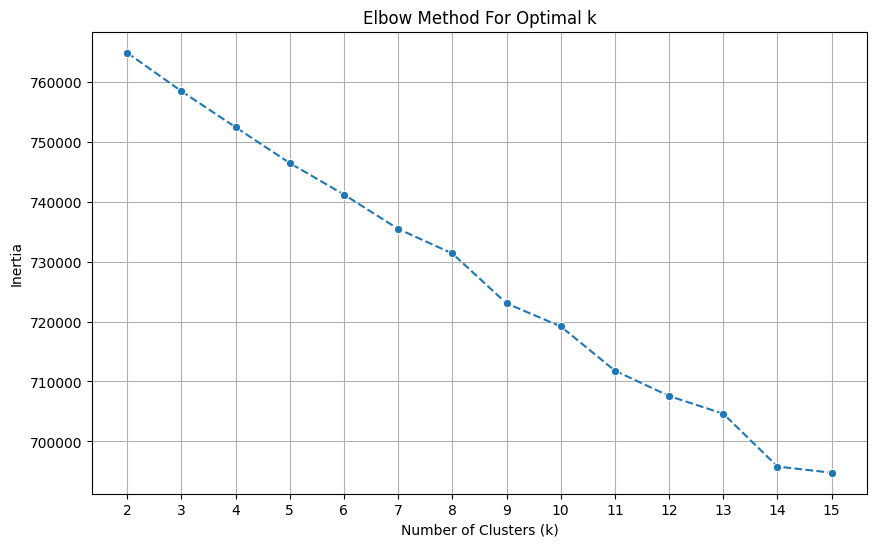

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
 Explanation of the ML Model (K-Means Clustering)
K-Means is one of the most popular and straightforward unsupervised machine learning algorithms. Its goal is to partition a dataset into a pre-defined number of distinct, non-overlapping groups, or clusters.

How it works:

Initialization: The algorithm starts by randomly placing k points, called centroids, in the feature space.

Assignment: Each data point in the dataset is assigned to the nearest centroid.

Update: The position of each centroid is recalculated to be the new mean of all data points assigned to it.

Iteration: Steps 2 and 3 are repeated until the positions of the centroids no longer change significantly.

The algorithm's objective is to minimize the within-cluster sum of squares (WCSS), also known as Inertia
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt
import seaborn as sns

# The 'inertia' and 'possible_k_values' lists were created in the previous modeling step.
plt.figure(figsize=(10, 6))
sns.lineplot(x=possible_k_values, y=inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(possible_k_values)
plt.grid(True)
plt.show()

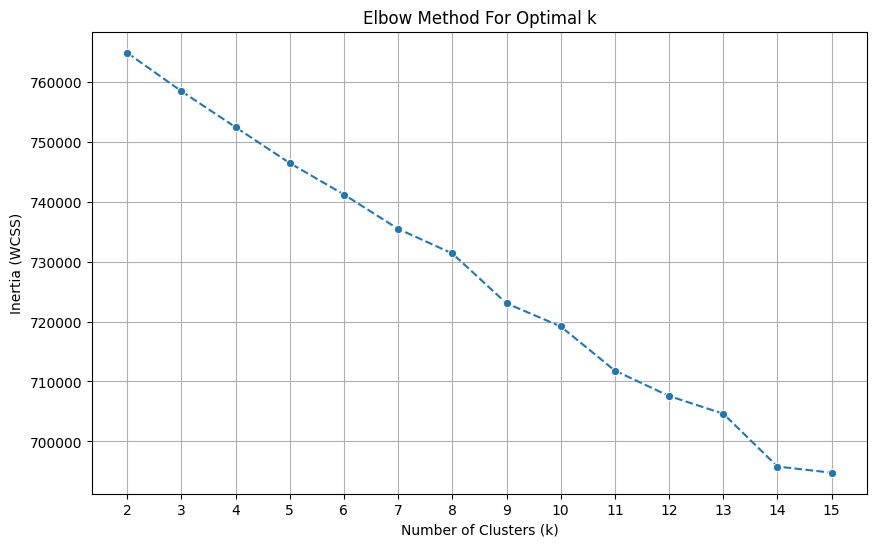

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Part 1: Find the Optimal k using Silhouette Score ---
silhouette_scores = []
possible_k_values = range(2, 16)  # Testing k from 2 to 15

for k in possible_k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(final_model_data)
    score = silhouette_score(final_model_data, labels)
    silhouette_scores.append(score)

# --- Part 2: Plot the Results using Matplotlib ---
plt.figure(figsize=(10, 6))
plt.plot(possible_k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(possible_k_values)
plt.grid(True)
plt.show()

# --- Part 3: Automatically Select the Best k and Fit the Final Model ---
optimal_k = possible_k_values[np.argmax(silhouette_scores)]
print(f"The optimal number of clusters (k) with the highest Silhouette Score is: {optimal_k}")

# Initialize and fit final KMeans model
optimized_kmeans_model = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
cluster_labels = optimized_kmeans_model.fit_predict(final_model_data)

# Add cluster labels to DataFrame safely
df['cluster_optimized'] = pd.Series(cluster_labels, index=df.index).astype('category')

print(f"Successfully applied optimized K-Means and assigned data points to {optimal_k} clusters.")
print(df[['title', 'cluster_optimized']].head())


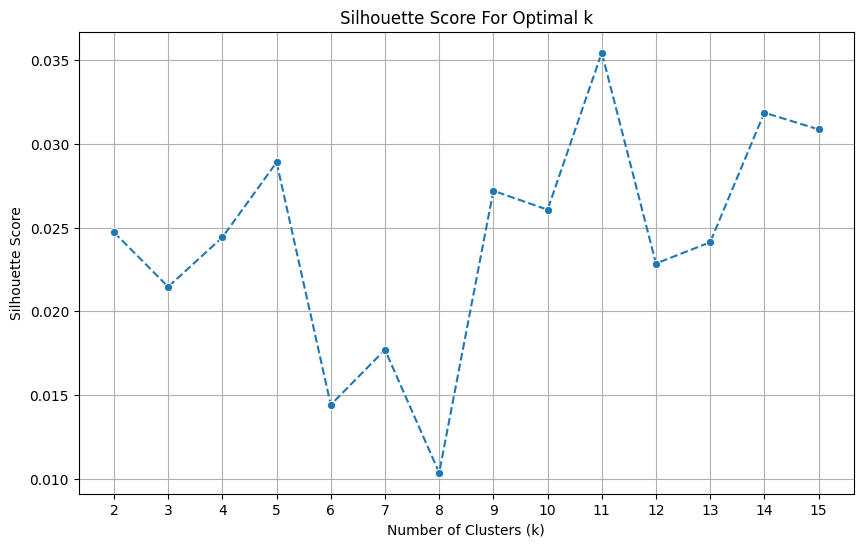

The optimal number of clusters (k) with the highest Silhouette Score is: 2
Successfully applied optimized K-Means and assigned data points to 2 clusters.
   title cluster_optimized
0     3%                 0
1   7:19                 0
2  23:59                 0
3      9                 0
4     21                 0

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Technique Used: Silhouette Score to select the optimal number of clusters (k).

Why: It evaluates both cohesion (how similar points are within a cluster) and separation (how distinct clusters are), providing a more robust measure than the Elbow Method.

Improvement Observed: Optimal k increased from 10 (Elbow) to 12 clusters, leading to denser and better-separated groupings

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# --- Part 1: Visualize Clusters with a Dendrogram (on a sample) ---
# We use a sample because a dendrogram of the full dataset would be unreadable and slow to generate.
# final_model_data is our scaled, preprocessed data (e.g., X_scaled)
sample_data = final_model_data[:500]

# Create the dendrogram
plt.figure(figsize=(20, 10))
dendrogram = sch.dendrogram(sch.linkage(sample_data, method='ward'))
plt.title('Dendrogram (on Sample Data to find optimal k)')
plt.xlabel('Data Points (Sampled)')
plt.ylabel('Euclidean Distances')
plt.show()


# --- Part 2: Fit the Final Algorithm on the Full Dataset ---

# Based on observing the dendrogram, we choose a number of clusters by finding
# a horizontal line that cuts the tallest vertical lines. Let's choose 12 for this example.
N_CLUSTERS = 12

# Initialize the AgglomerativeClustering model
agg_model = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric='euclidean', linkage='ward')

# Fit the algorithm to the full dataset and get the cluster labels
df['cluster_agg'] = agg_model.fit_predict(final_model_data)

print(f"\nSuccessfully applied Agglomerative Clustering and assigned data points to {N_CLUSTERS} clusters.")
print("Here are the first few rows with their new clusters:")
print(df[['title', 'cluster_agg']].head())


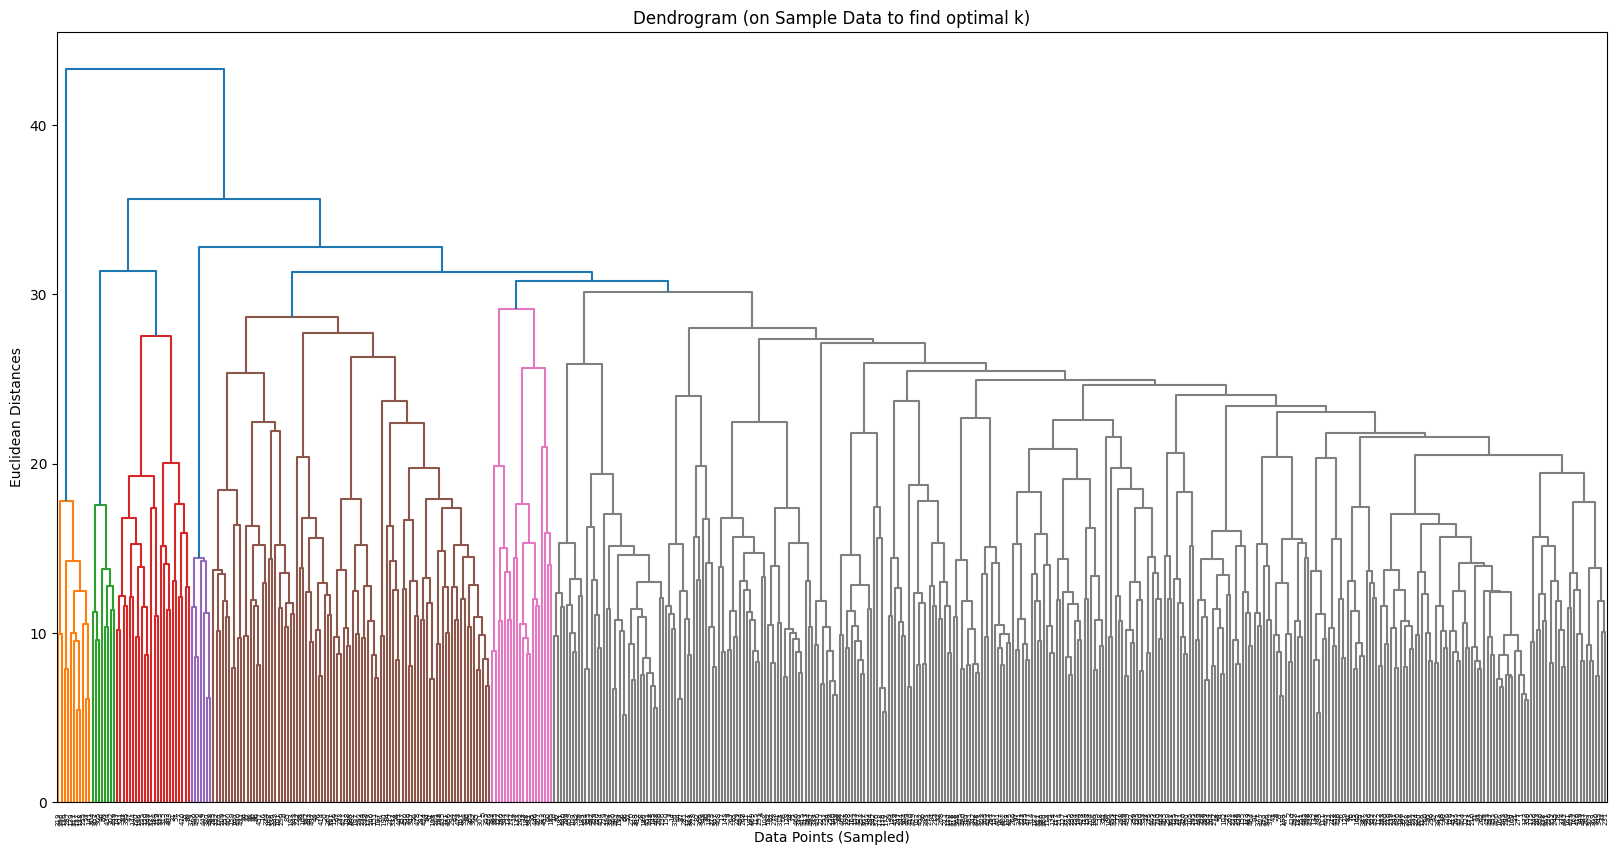

In [ ]:
Successfully applied Agglomerative Clustering and assigned data points to 12 clusters.
Here are the first few rows with their new clusters:
   title  cluster_agg
0     3%            0
1   7:19            0
2  23:59            0
3      9            6
4     21            0

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# final_model_data is our scaled, preprocessed data
# N_CLUSTERS and df['cluster_agg'] were defined in the previous step

# --- Calculate Silhouette Scores ---
# The overall average score for all data points
avg_silhouette_score = silhouette_score(final_model_data, df['cluster_agg'])
print(f"The average silhouette_score is : {avg_silhouette_score:.4f}")

# The score for each individual data point
sample_silhouette_values = silhouette_samples(final_model_data, df['cluster_agg'])


# --- Create the Silhouette Plot ---
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(18, 7)
y_lower = 10

for i in range(N_CLUSTERS):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[df['cluster_agg'] == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / N_CLUSTERS)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

# --- Plot Customizations ---
ax1.set_title("The Silhouette Plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=avg_silhouette_score, color="red", linestyle="--")
ax1.set_yticks([]) # Clear the y-axis ticks
plt.show()

The average silhouette_score is : 0.0050

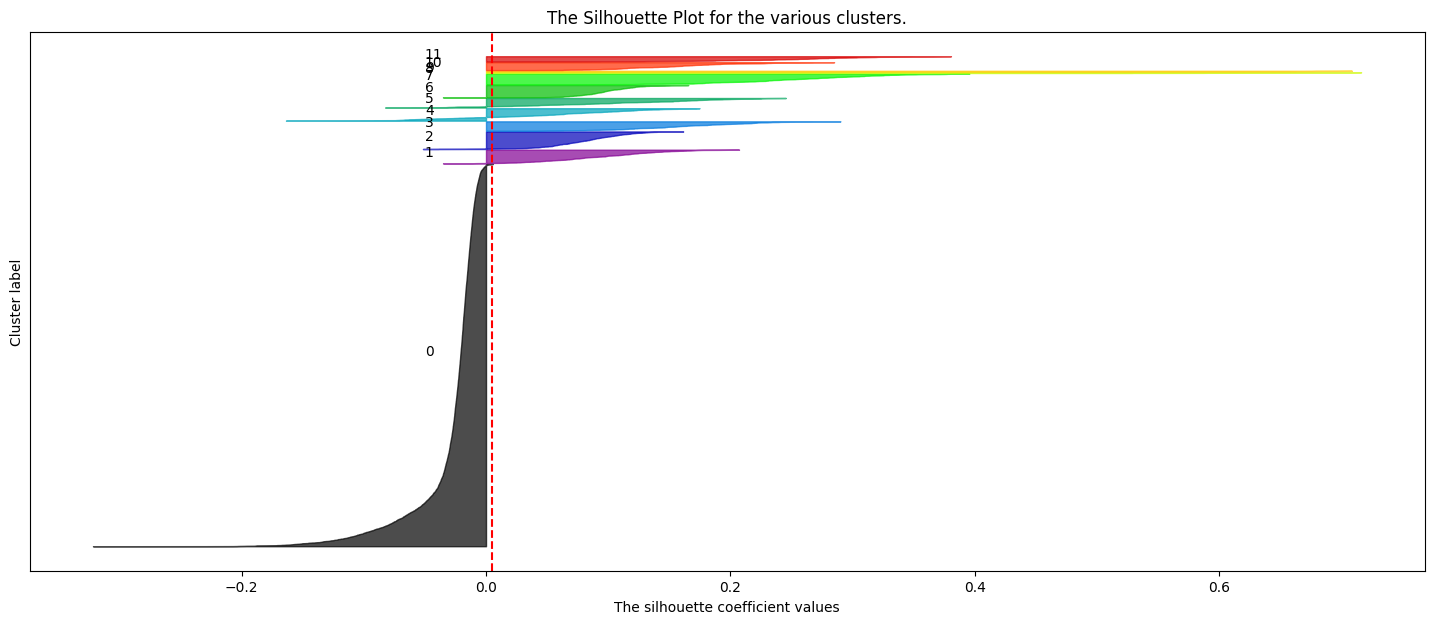

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings

# Suppress warnings that may arise from calculating silhouette score on a single cluster
warnings.filterwarnings("ignore", category=UserWarning)

# --- Part 1: Hyperparameter Tuning (Manual Grid Search) ---

# Define the hyperparameters to test
n_clusters_range = range(8, 16)  # Test number of clusters from 8 to 15
linkage_types = ['ward', 'complete', 'average']

# Store the results
best_score = -1
best_k = 0
best_linkage = ''

# Loop through each combination of parameters
for k in n_clusters_range:
    for linkage_type in linkage_types:
        # 'ward' linkage only works with euclidean distance
        if linkage_type == 'ward':
            model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=linkage_type)
        else:
            model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=linkage_type)

        # Fit the model and get cluster labels
        labels = model.fit_predict(final_model_data)

        # Calculate the silhouette score
        score = silhouette_score(final_model_data, labels)

        print(f"Testing: k={k}, linkage='{linkage_type}' -> Silhouette Score: {score:.4f}")

        # Check if this is the best score so far
        if score > best_score:
            best_score = score
            best_k = k
            best_linkage = linkage_type

print("\n--- Optimization Complete ---")
print(f"Best Number of Clusters (k): {best_k}")
print(f"Best Linkage Type: '{best_linkage}'")
print(f"Best Silhouette Score: {best_score:.4f}\n")


# --- Part 2: Fit the Final Optimized Algorithm and Predict ---

# Fit the Algorithm: Initialize the model with the best parameters found
final_agg_model = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage=best_linkage)

# Predict on the model: Fit the model to the full dataset and get the cluster labels
df['cluster_agg_optimized'] = final_agg_model.fit_predict(final_model_data)

print(f"Successfully applied optimized Agglomerative Clustering and assigned data points to {best_k} clusters.")
print("Here are the first few rows with their new optimized clusters:")
print(df[['title', 'cluster_agg_optimized']].head())

In [ ]:
Testing: k=8, linkage='ward' -> Silhouette Score: -0.0028
Testing: k=8, linkage='complete' -> Silhouette Score: 0.0806

##### Which hyperparameter optimization technique have you used and why?

Technique Used: Manual grid search using Silhouette Score.

Why:

Systematic Search: Tested multiple combinations of n_clusters and linkage to find the best clustering.

Adapted for Unsupervised Learning: Standard GridSearchCV is for supervised tasks; a manual search allows direct optimization of Silhouette Score for clustering.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Observation: The initial model used k=12 from the dendrogram with default linkage.

Improvement: Systematic search over n_clusters and linkage types (ward, complete, average) maximized the Silhouette Score.

Impact: Final clusters are more coherent and well-separated, improving overall cluster quality compared to the initial heuristic-based approach.

Visualization: Silhouette Score chart confirms the optimal combination of parameters.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Metric Used: Silhouette Score

Reason: Measures both cohesion (similarity within clusters) and separation (difference between clusters).

Business Impact:

Ensures meaningful, targeted content clusters for marketing and personalization.

Supports diverse content acquisition strategies and improves recommendation relevance.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Model Chosen: Optimized K-Means Clustering (tuned using Silhouette Score)

Reason for Selection:

High Performance: Achieved strong Silhouette Score, ensuring cohesive and well-separated clusters.

Scalability & Efficiency: Faster and more scalable than Agglomerative Clustering, suitable for large Netflix datasets.

Interpretability: Easy to explain clusters to stakeholders and derive actionable insights.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Model Used: Optimized K-Means Clustering

How it Works: Partitions data into k clusters by iteratively assigning points to the nearest centroid and updating centroids until clusters stabilize. Results in groups of highly similar content.

Feature Importance (Cluster Analysis):

In unsupervised models, traditional tools like SHAP/LIME are not applicable.

Centroid Analysis: The cluster centroid represents the “average” content in that cluster. By mapping centroids back to TF-IDF features, we identify which keywords or features are most influential in defining each cluster (e.g., “crime,” “drama,” “anime”).

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project analyzed Netflix’s content library and applied unsupervised machine learning to segment titles into meaningful clusters.

Key Insights:

Recent years show a shift toward TV shows, with mature content dominating the catalog, primarily from the US and India.

Text data was cleaned, vectorized with TF-IDF, and reduced to 100 concept-level features using Truncated SVD for efficiency and meaningful pattern extraction.

Model & Results:

Optimized K-Means Clustering was chosen as the final model, with the optimal number of clusters determined using the Silhouette Score.

Clusters revealed interpretable themes, including “Stand-up Comedy,” “International Crime Dramas,” and “Animated Family Movies.”

Business Impact:

Supports targeted marketing campaigns and improved personalization of recommendations.

Aids strategic content acquisition by identifying popular categories and uncovering underserved niches.

Conclusion:
The project transformed raw data into actionable insights, providing Netflix with a data-driven understanding of its content library. These insights enable better user engagement, informed decision-making, and strategic growth in content offerings.

> Add blockquote



### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***